 **This version we are trying fine tuning the emodel for multiple variable values.. Only minor issue is with the vehicle count and cooldown. There is a place for improvement.**

## 1. System Setup

### Imports and Installs

#### Installs

In [928]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape

#### Imports

In [929]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [930]:
import numpy as np
import pickle
import random
import json
from itertools import permutations
import time as time_module
import networkx as nx
from datetime import datetime
import geopy.distance
import heapq
import math
import heapq
import pickle
import os


# ============================================================
# IMPORTS - Add at the top of your notebook
# ============================================================

import pandas as pd
import json
import numpy as np
import pickle
import random
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import viridis
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from shapely.geometry import Point, Polygon
import requests
import time
import sys
import ast
import geopandas as gpd
from collections import defaultdict
from tqdm import tqdm
import heapq
import math
import networkx as nx
from datetime import datetime
import geopy.distance
from itertools import product
import seaborn as sns

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

In [931]:
# Add this JSON encoder class
class NumpyEncoder(json.JSONEncoder):
    """Custom JSON encoder that handles NumPy types."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

### Parameters

In [932]:
state_name = "Ohio"
city_name = "Columbus"
mini = True

### Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [933]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


### Assign Data directory path

In [934]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"
output_dir = data_dir + "/UMST Graph/bundling"


In [935]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Output directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/bundling
Files in directory :  ['Census Data', 'Images', 'Hotspot Data', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'UMST Graph', 'gh_cache', 'Deliveries', 'avg_hotspot_data.json', 'experiment_results', 'simulation_results', 'results_multiply', 'results_fixed_buffer', 'results_rangewise', 'results_randomized']


#### Global Variables and Functions

In [936]:
# Changed the directory
deliveries_dir = data_dir + f"/Deliveries"
try:
  os.mkdir(deliveries_dir)
except:
  print(deliveries_dir + " Already Exists")

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Deliveries Already Exists



## Simulation Materials

### 2. Deliveries

#### 2. Delivery Class

In [937]:
# ============================================================
# 1. DELIVERY CLASS - Enhanced with Raw Data Tracking
# ============================================================
class Delivery:
    """
    Represents a single delivery request with comprehensive tracking.
    """
    id_counter = 0

    def __init__(self, start_node, end_node, start_time, buffer_time_type,
                 time_tolerance_factor, shortest_path=None):
        # Identity
        self.id = Delivery.id_counter
        Delivery.id_counter += 1

        # Route (immutable)
        self.start_node = start_node
        self.end_node = end_node
        self.shortest_path = shortest_path if shortest_path else [start_node, end_node]

        # Time constraints
        self.start_time = start_time
        self.TIME_TOLERANCE_FACTOR = time_tolerance_factor
        self.buffer_time_type = buffer_time_type
        self.time_limit = None  # Set after initialization
        self.expected_travel_time = 0  # Pure travel time without buffer

        # Current state (mutable)
        self.current_node = start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0

        # Completion tracking
        self.completed = False
        self.successful = False
        self.end_time = None

        # Enhanced Statistics
        self.distance_traveled = 0
        self.actual_path = [start_node]
        self.num_vehicle_changes = 0
        self.times_bundled = 0
        self.total_wait_time = 0
        self.bundle_history = []  # List of (step, bundle_id, action)

        # NEW: Detailed tracking for metrics
        self.actual_delivery_time = 0  # End to end time
        self.delay = 0  # Actual time - expected time
        self.within_buffer = False  # Met expected + buffer?
        self.package_km = 0  # Distance * 1 package

        # Bundle reference
        self.current_bundle_id = None

    def get_next_node(self):
        """Get next node in planned path."""
        if self.path_index < len(self.shortest_path) - 1:
            return self.shortest_path[self.path_index + 1]
        return None

    def move_to_next_node(self, distance, travel_time):
        """Start transition to next node."""
        self.in_transition = True
        self.time_till_next_node = travel_time
        self.distance_traveled += distance
        self.package_km = distance  # 1 package * distance

    def arrive_at_node(self, node):
        """Complete arrival at node."""
        self.in_transition = False
        self.current_node = node
        self.actual_path.append(node)
        self.path_index += 1

        if self.current_node == self.end_node:
            self.completed = True

    def finalize_metrics(self, vehicle_change_time):
        """Calculate final metrics after delivery completion."""
        if self.completed and self.end_time:
            # Actual delivery time including penalties
            self.actual_delivery_time = (self.end_time - self.start_time) + \
                                       (self.num_vehicle_changes * vehicle_change_time)

            # Delay calculation
            # self.delay = self.actual_delivery_time - self.time_limit
            self.delay = max(0, self.actual_delivery_time - self.time_limit)

            # Within buffer check
            self.within_buffer = self.actual_delivery_time <= self.time_limit
            self.successful = self.within_buffer

    def reset(self):
        """Reset to initial state."""
        self.current_node = self.start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0
        self.completed = False
        self.successful = False
        self.end_time = None
        self.distance_traveled = 0
        self.actual_path = [self.start_node]
        self.num_vehicle_changes = 0
        self.current_bundle_id = None
        self.total_wait_time = 0
        self.bundle_history = []
        self.actual_delivery_time = 0
        self.delay = 0
        self.within_buffer = False
        self.times_bundled = 0

        # NEW: Clear vehicle references from previous baseline runs
        if hasattr(self, '_dedicated_vehicle_id'):
            delattr(self, '_dedicated_vehicle_id')
        if hasattr(self, '_dedicated_vehicle'):
            delattr(self, '_dedicated_vehicle')


    def __repr__(self):
        status = "✅" if self.completed else ("🚗" if self.in_transition else "⏳")
        bundle = f"[B{self.current_bundle_id}]" if self.current_bundle_id else ""
        return f"D{self.id}:{self.start_node}→{self.end_node}|{status}{bundle}@N{self.current_node}"


#### 3. Vehicle Class

In [938]:
# ============================================================
# 2. VEHICLE CLASS - Enhanced Tracking
# ============================================================
class Vehicle:
    """
    Represents a physical vehicle with comprehensive metrics.
    """
    id_counter = 0

    def __init__(self, start_node, allow_reuse=True):
        self.id = Vehicle.id_counter
        Vehicle.id_counter += 1

        self.current_node = start_node
        self.allow_reuse = allow_reuse

        # Cumulative stats
        self.total_distance = 0
        self.total_trips = 0
        self.all_deliveries_carried = set()
        self.trip_history = []  # List of (start_time, end_time, deliveries, distance)

        # Current trip
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.current_trip_start_time = 0
        self.is_in_use = False

        # Reuse management
        self.available_at_time = 0
        self.cooldown_period = 0

    def move_to(self, next_node, distance):
        """Move vehicle to next node."""
        self.current_node = next_node
        self.total_distance += distance
        self.current_trip_distance += distance
        self.current_route.append(next_node)

    def start_new_trip(self, start_node, current_time):
        """Prepare for new trip (reuse)."""
        if not self.allow_reuse:
            raise ValueError("Vehicle reuse not allowed in baseline mode")

        self.current_node = start_node
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.current_trip_start_time = current_time
        self.total_trips += 1
        self.is_in_use = True
        self.available_at_time = 0

    def release(self, current_time):
        """Mark as available for reuse after cooldown."""
        self.is_in_use = False
        if self.allow_reuse:
            self.available_at_time = current_time + self.cooldown_period

    def can_reuse(self, current_time):
        """Check if vehicle can be reused."""
        return self.allow_reuse and not self.is_in_use and current_time >= self.available_at_time

    def __repr__(self):
        return f"V{self.id}@N{self.current_node}|{self.total_distance/1000:.1f}km"

#### 4. Delivery Bundle Class

In [939]:
# ============================================================
# 3. BUNDLE CLASS - No Changes Needed
# ============================================================
class Bundle:
    """
    Manages a group of deliveries sharing a vehicle.
    """
    id_counter = 0

    def __init__(self, delivery_ids, vehicle, current_node, next_node, step):
        self.id = Bundle.id_counter
        Bundle.id_counter += 1

        self.delivery_ids = set(delivery_ids)
        self.vehicle = vehicle
        self.current_node = current_node
        self.next_node = next_node
        self.created_at_step = step

        self.is_active = True
        self.dissolved_at_step = None
        self.dissolution_reason = None

    def add_delivery(self, delivery_id):
        self.delivery_ids.add(delivery_id)

    def remove_delivery(self, delivery_id):
        self.delivery_ids.discard(delivery_id)

    def dissolve(self, step, reason):
        self.is_active = False
        self.dissolved_at_step = step
        self.dissolution_reason = reason

    def size(self):
        return len(self.delivery_ids)

    def __repr__(self):
        status = "🟢" if self.is_active else "🔴"
        return f"{status}Bundle{self.id}:[{','.join(f'D{d}' for d in sorted(self.delivery_ids))}]@V{self.vehicle.id}"

#### 5. DeliveryList Class

In [940]:
# ============================================================
# 4. DELIVERYLIST CLASS - Enhanced with Buffer Time Types
# ============================================================
class DeliveryList:
    """
    Manages collection of deliveries with configurable buffer strategies.
    """

    def __init__(self, max_delivery_time, load, time_tolerance_factor,
                 buffer_time_type="multiply",  # NEW PARAMETER
                 hours=1, peaks=[0.25, 0.75], sigma=10, num_hotspots=50,
                 adjacency_matrix=None, node_positions=None):

        self.load = load
        self.hours = hours
        self.peaks = peaks
        self.sigma = sigma
        self.time_tolerance_factor = time_tolerance_factor
        self.buffer_time_type = buffer_time_type  # NEW
        self.max_delivery_time = max_delivery_time
        self.num_hotspots = num_hotspots
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions

        if adjacency_matrix is None or node_positions is None:
            raise ValueError("adjacency_matrix and node_positions are required!")

        # Generate deliveries
        self.distribution, self.loads = self.generate_distribution()
        self.computed_paths = {}
        self.deliveries = self.generate_deliveries()
        self.calculate_time_limits()

    def generate_distribution(self):
        """Generate temporal distribution of deliveries."""
        mu_list = [peak * 60 * self.hours for peak in self.peaks]
        x = np.linspace(0, 60 * self.hours, 60 * self.hours)

        y_combined = np.zeros_like(x)
        for mu in mu_list:
            y_combined += (1 / (self.sigma * np.sqrt(2 * np.pi))) * \
                         np.exp(-0.5 * ((x - mu) / self.sigma) ** 2)

        loads = [int((self.load * (self.sigma * np.sqrt(2 * np.pi))) * y)
                for y in y_combined]

        return y_combined, loads

    def get_travel_time(self, start, end):
        """Get pre-computed travel time between two nodes."""
        if start == end:
            return 0

        if (start, end) not in self.computed_paths:
            return float('inf')

        travel_time, path = self.computed_paths[(start, end)]
        return travel_time

    def calculate_time_limits(self):
        """
        Calculate time limits for all deliveries using buffer strategies.
        """
        for delivery in self.deliveries:
            # Get base travel time
            travel_time = self.get_travel_time(
                delivery.start_node,
                delivery.end_node
            )

            delivery.expected_travel_time = travel_time

            # Calculate required time based on buffer strategy
            if self.buffer_time_type == "multiply":
                required_time = travel_time * delivery.TIME_TOLERANCE_FACTOR

            elif self.buffer_time_type == "randomized":
                required_time = travel_time + random.randint(2, 8) * 60  # 2-8 mins

            elif self.buffer_time_type == 'fixed_buffer':
                required_time = travel_time + 5 * 60  # 5 mins for all

            elif self.buffer_time_type == 'rangewise':
                if travel_time <= 10 * 60:
                    required_time = travel_time + 2 * 60  # 2mins
                elif travel_time <= 20 * 60:
                    required_time = travel_time + 5 * 60  # 5mins
                elif travel_time <= 30 * 60:
                    required_time = travel_time + 7 * 60  # 7mins
                else:
                    required_time = travel_time + 10 * 60  # 10mins
            else:
                required_time = travel_time * delivery.TIME_TOLERANCE_FACTOR

            delivery.time_limit = required_time

    def generate_deliveries(self):
        """Generate delivery requests using pre-computed or dynamically computed paths."""
        deliveries = []
        total_deliveries = sum(self.loads)
        valid_nodes = list(range(self.num_hotspots))

        max_attempts_limit = int(20 * total_deliveries)
        total_attempts = 0

        with tqdm(total=total_deliveries, desc="Creating deliveries", leave=False) as pbar:
            for j in range(60 * self.hours):
                for _ in range(self.loads[j]):
                    valid_pair_found = False

                    while total_attempts < max_attempts_limit:
                        total_attempts += 1
                        start = random.choice(valid_nodes)
                        end = random.choice(valid_nodes)
                        if end == start:
                            continue

                        # Either use precomputed or compute dynamically
                        travel_time, shortest_path = astar_shortest_path(
                            adjacency=self.adjacency_matrix,
                            start=start,
                            goal=end,
                            node_positions=self.node_positions,
                            weight_type='time'
                        )

                        # Check travel time constraint
                        if travel_time != float('inf') and travel_time <= self.max_delivery_time:
                            valid_pair_found = True
                            break

                    if not valid_pair_found:
                        raise RuntimeError(
                            f"Failed to generate valid deliveries within "
                            f"{max_attempts_limit} total attempts (max allowed {self.max_delivery_time / 60:.1f} min)."
                        )

                    # Store result
                    self.computed_paths[(start, end)] = (travel_time, shortest_path)
                    time = random.randint(j * 60, (j + 1) * 60)

                    delivery = Delivery(
                        start, end, time,
                        buffer_time_type=self.buffer_time_type,
                        time_tolerance_factor=self.time_tolerance_factor,
                        shortest_path=shortest_path
                    )
                    deliveries.append(delivery)
                    pbar.update(1)

        return deliveries


    def reset_deliveries(self):
        """Reset all deliveries to their initial state."""
        for d in self.deliveries:
            d.reset()

### 3. Simulation

In [941]:
# ============================================================
# 5. SIMULATION CLASS - Orchestrates everything (Adjacency Matrix Version)
# ============================================================

class Simulation:
    """
    Main simulation engine with comprehensive metrics tracking.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots,
                 wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                 vehicle_cooldown=600, debug=False):

        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions
        self.num_hotspots = num_hotspots
        self.wait_time = wait_time
        self.max_bundle_size = max_bundle_size
        self.vehicle_change_time = vehicle_change_time
        self.vehicle_cooldown = vehicle_cooldown
        self.debug = debug

        # Time
        self.clock = 0
        self.time_step = 10
        self.step_count = 0

        # Deliveries
        self.all_deliveries = {d.id: d for d in deliverylist.deliveries}
        self.active_deliveries = set()
        self.dormant_deliveries = set(d.id for d in deliverylist.deliveries)

        # Bundles
        self.bundles = {}
        self.active_bundles = set()

        # Vehicles
        self.vehicles = {}
        self.available_vehicles = []
        self.use_bundling = True

        # Statistics
        self.bundles_created = 0
        self.bundles_dissolved = 0
        self.bundles_merged = 0
        self.peak_active_vehicles = 0
        self.active_vehicles_history = []
        self.bundle_peak_sizes = []

        # NEW: Raw data storage for post-facto analysis
        self.raw_simulation_data = {
            'deliveries': [],
            'vehicles': [],
            'bundles': [],
            'timeline': []
        }

    def get_edge_info(self, from_node, to_node):
      """Get distance and time for edge."""
      if from_node not in self.adjacency_matrix:
          return None, None
      for neighbor_idx, dist, time in self.adjacency_matrix[from_node]:
          if neighbor_idx == to_node:
              return dist, time
      return None, None

    def run(self, grace_time, use_bundling=True):
        """Run simulation."""
        self.use_bundling = use_bundling  # Store for vehicle creation
        max_time = self.deliverylist.hours * 60 * 60 + grace_time

        mode = "BUNDLING" if use_bundling else "BASELINE"
        print(f"\n{'='*80}")
        print(f"🚀 {mode} SIMULATION")
        print(f"{'='*80}")
        print(f"⏱️  Max time: {max_time}s ({max_time/3600:.2f}hr)")
        print(f"⏳ Wait time: {self.wait_time}s")
        print(f"🚗 Max bundle: {self.max_bundle_size} deliveries")
        if use_bundling:
            print(f"🔄 Vehicle cooldown: {self.vehicle_cooldown}s")
        print(f"📦 Total deliveries: {len(self.all_deliveries)}")
        print(f"{'='*80}\n")

        while self.clock < max_time and (self.active_deliveries or self.dormant_deliveries):
            self.step(use_bundling)

            if self.clock % 600 == 0 and self.debug:
                self.print_status()

        self.finalize_results()
        self.print_summary()

    def step(self, use_bundling):
        """Execute one simulation step."""
        self.step_count += 1

        # Phase 1: Activate new deliveries
        self.activate_deliveries()

        # Phase 2: Move all deliveries in transit
        self.move_deliveries()

        # Phase 3: Handle bundling logic
        if use_bundling:
            self.handle_unbundling()  # Dissolve diverging bundles
            self.handle_bundling()    # Create/merge bundles
        else:
            self.handle_baseline()    # Individual vehicles

        # Phase 4: Track metrics
        self.track_metrics()

        # Advance time
        self.clock += self.time_step

    def activate_deliveries(self):
        """Move deliveries from dormant to active."""
        to_activate = [d_id for d_id in self.dormant_deliveries
                       if self.all_deliveries[d_id].start_time <= self.clock]

        for d_id in to_activate:
            self.active_deliveries.add(d_id)
            self.dormant_deliveries.remove(d_id)

            if self.debug and len(to_activate) <= 3:
                print(f"  📦 NEW: {self.all_deliveries[d_id]}")

        if self.debug and len(to_activate) > 3:
            print(f"  📦 {len(to_activate)} new deliveries")

    def move_deliveries(self):
        """Move all deliveries in transit."""
        completed = []

        for d_id in list(self.active_deliveries):
            delivery = self.all_deliveries[d_id]

            # TRANSIT: Delivery is moving between nodes
            if delivery.in_transition:
                delivery.time_till_next_node -= self.time_step

                if delivery.time_till_next_node <= 0:
                    # ARRIVAL at next node
                    next_node = delivery.get_next_node()
                    if next_node is None:
                        # Something wrong - shouldn't be in transition if no next node
                        if self.debug:
                            print(f"  ⚠️ WARNING: D{d_id} in transition but no next node")
                        delivery.in_transition = False
                        continue

                    delivery.arrive_at_node(next_node)

                    # Check if completed (reached destination)
                    if delivery.completed:
                        delivery.end_time = self.clock
                        completed.append(d_id)

                        if self.debug:
                            print(f"  ✅ D{d_id} COMPLETED at N{delivery.current_node} (time={self.clock}s)")

                        # Remove from bundle if bundled
                        if delivery.current_bundle_id:
                            self.remove_from_bundle(d_id, "completed")
                    else:
                        # Not at destination yet - reset wait time for potential rebundling
                        if not delivery.current_bundle_id:
                            delivery.wait_time_remaining = self.wait_time
                continue

            # WAITING: Decrement wait time for deliveries not in transit
            # print(f"Debug:: {delivery.completed} and {delivery.wait_time_remaining}")
            if not delivery.completed and delivery.wait_time_remaining > 0:
                delivery.wait_time_remaining -= self.time_step

        # Remove completed deliveries
        for d_id in completed:
            self.active_deliveries.remove(d_id)

    def handle_unbundling(self):
        """
        Check and dissolve bundles with diverging paths.
        IMPROVED: Keeps partial bundles alive if 2+ deliveries still share path.
        """
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            # Group deliveries by next destination
            next_destinations = defaultdict(list)
            for d_id in list(bundle.delivery_ids):
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    next_node = delivery.get_next_node()
                    next_destinations[next_node].append(d_id)

            # If all going to same place, continue
            if len(next_destinations) <= 1:
                continue

            # Paths diverge - need to split bundle
            if self.debug:
                print(f"    🔀 SPLIT: Bundle{bundle_id} diverging to {len(next_destinations)} destinations")

            # Dissolve original bundle
            self.dissolve_bundle(bundle_id, "path_divergence")

            # Create NEW bundles for each group of 2+
            for next_node, delivery_ids in next_destinations.items():
                if next_node is None:
                    # Deliveries completed - skip
                    continue

                if len(delivery_ids) >= 2:
                    # Still enough to bundle
                    current_node = self.all_deliveries[delivery_ids[0]].current_node
                    self.create_bundle(delivery_ids, current_node, next_node)

                    if self.debug:
                        print(f"      ↳ Sub-bundle created: [{','.join(f'D{d}' for d in delivery_ids)}] → N{next_node}")
                elif len(delivery_ids) == 1:
                    # Single delivery - let it wait for new partners
                    d_id = delivery_ids[0]
                    delivery = self.all_deliveries[d_id]
                    delivery.wait_time_remaining = self.wait_time

                    if self.debug:
                        print(f"      ↳ D{d_id} now solo, waiting for partners")
                else:
                   continue  # Skip empty groups

    def handle_bundling(self):
        """Create and merge bundles at each node."""
        # Group deliveries by (current_node, next_node)
        node_groups = defaultdict(lambda: defaultdict(list))

        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is not None:
                node_groups[delivery.current_node][next_node].append(d_id)
            elif next_node is None and delivery.current_node != delivery.end_node:
                # Delivery thinks it has no next node but hasn't reached destination
                # This shouldn't happen but let's mark it as stuck
                if self.debug:
                    print(f"  ⚠️ WARNING: D{d_id} has no next node but not at destination!")
                    print(f"     Current: N{delivery.current_node}, Target: N{delivery.end_node}")
                    print(f"     Path: {delivery.shortest_path}, Index: {delivery.path_index}")

        # Process each (current_node, next_node) group
        for current_node, dest_groups in node_groups.items():
            for next_node, delivery_ids in dest_groups.items():

                if len(delivery_ids) < 2:
                    # Lone delivery - set wait time
                    for d_id in delivery_ids:
                        delivery = self.all_deliveries[d_id]
                        if delivery.wait_time_remaining == 0 and not delivery.current_bundle_id:
                            delivery.wait_time_remaining = self.wait_time
                    continue

                # Separate bundled vs unbundled
                bundled = defaultdict(list)  # bundle_id -> delivery_ids
                unbundled = []

                for d_id in delivery_ids:
                    delivery = self.all_deliveries[d_id]
                    if delivery.current_bundle_id:
                        bundled[delivery.current_bundle_id].append(d_id)
                    elif delivery.wait_time_remaining <= 0:
                        unbundled.append(d_id)

                # STRATEGY 1: Merge existing bundles
                if len(bundled) > 1:
                    all_bundled = []
                    for bundle_deliveries in bundled.values():
                        all_bundled.extend(bundle_deliveries)

                    if len(all_bundled) <= self.max_bundle_size:
                        # Dissolve old bundles and create merged bundle
                        for bundle_id in bundled.keys():
                            self.dissolve_bundle(bundle_id, "merge")

                        self.create_bundle(all_bundled, current_node, next_node)
                        self.bundles_merged += 1
                        continue

                # STRATEGY 2: Add unbundled to existing bundles
                for bundle_id, bundle_deliveries in bundled.items():
                    bundle = self.bundles[bundle_id]
                    slots_available = self.max_bundle_size - bundle.size()

                    if slots_available > 0 and unbundled:
                        to_add = unbundled[:slots_available]
                        unbundled = unbundled[slots_available:]

                        for d_id in to_add:
                            self.add_to_bundle(bundle_id, d_id)

                # STRATEGY 3: Create new bundles from unbundled
                while len(unbundled) >= 2:
                    group = unbundled[:self.max_bundle_size]
                    unbundled = unbundled[self.max_bundle_size:]

                    self.create_bundle(group, current_node, next_node)

                # STRATEGY 4: Remaining singles - initiate movement immediately
                for d_id in unbundled:
                    delivery = self.all_deliveries[d_id]
                    if delivery.wait_time_remaining <= 0:
                        # Waited long enough - move solo
                        self.initiate_delivery_movement(d_id, current_node, next_node)
                    else:
                        # # Still waiting for partners
                        # if delivery.wait_time_remaining == 0:
                        #     delivery.wait_time_remaining = self.wait_time
                         # Still waiting, keep its remaining wait time
                        if self.debug:
                            print(f"      ↳ D{d_id} remains waiting ({delivery.wait_time_remaining:.1f}s left)")

        # CRITICAL: Move all bundled deliveries that are ready
        self.move_bundled_deliveries()

    def handle_baseline(self):
        """
        Baseline: Each delivery gets individual vehicle (NO REUSE).
        FIXED: Store vehicle object reference, not just ID.
        """
        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is None:
                continue

            # Ready to move (no waiting in baseline for fairness)
            if delivery.wait_time_remaining <= 0:
                # FIXED: Store vehicle OBJECT on delivery, not just ID
                if not hasattr(delivery, '_dedicated_vehicle'):
                    # Create NEW vehicle for this delivery (no reuse in baseline)
                    vehicle = Vehicle(delivery.current_node, allow_reuse=False)
                    self.vehicles[vehicle.id] = vehicle
                    delivery._dedicated_vehicle = vehicle  # Store the object itself
                    delivery._dedicated_vehicle_id = vehicle.id  # Also store ID for get_results()
                    vehicle.is_in_use = True

                    if self.debug and self.clock < 100:
                        print(f"  🚗 NEW VEHICLE V{vehicle.id} for D{d_id}")
                else:
                    # Get vehicle from the stored object reference
                    vehicle = delivery._dedicated_vehicle

                # Get edge info using adjacency matrix
                distance, travel_time = self.get_edge_info(delivery.current_node, next_node)

                if distance is None or travel_time is None:
                    if self.debug:
                        print(f"  ⚠️ WARNING: No edge from N{delivery.current_node} to N{next_node}")
                    continue

                # Move delivery and vehicle together
                delivery.move_to_next_node(distance, travel_time)
                vehicle.move_to(next_node, distance)
                vehicle.all_deliveries_carried.add(d_id)
            else:
                delivery.wait_time_remaining -= self.time_step

    def create_bundle(self, delivery_ids, current_node, next_node):
        """Create new bundle."""
        if len(delivery_ids) < 2:
            return

        # Get vehicle (reuse if available and cooled down)
        vehicle = self.get_vehicle(current_node)

        # Create bundle
        bundle = Bundle(delivery_ids, vehicle, current_node, next_node, self.step_count)
        self.bundles[bundle.id] = bundle
        self.active_bundles.add(bundle.id)

        self.bundle_peak_sizes.append(len(delivery_ids))

        # Update deliveries
        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.current_bundle_id = bundle.id
            delivery.wait_time_remaining = 0
            delivery.num_vehicle_changes += 1
            delivery.times_bundled += 1

        # Get edge info using adjacency matrix
        distance, travel_time = self.get_edge_info(current_node, next_node)

        if distance is None or travel_time is None:
            if self.debug:
                print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
            return

        # Start movement for all deliveries in bundle
        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.move_to_next_node(distance, travel_time)

        # Move vehicle once (shared by all)
        vehicle.move_to(next_node, distance)
        for d_id in delivery_ids:
            vehicle.all_deliveries_carried.add(d_id)

        self.bundles_created += 1

        if self.debug:
            print(f"    🔗 BUNDLE{bundle.id} created @ N{current_node}: "
                  f"[{','.join(f'D{d}' for d in sorted(delivery_ids))}] → N{next_node} (V{vehicle.id})")

    def dissolve_bundle(self, bundle_id, reason):
        """Dissolve bundle and release vehicle with cooldown."""
        if bundle_id not in self.bundles:
            return

        bundle = self.bundles[bundle_id]
        bundle.dissolve(self.step_count, reason)

        # Clear delivery references
        for d_id in list(bundle.delivery_ids):
            if d_id in self.all_deliveries:
                self.all_deliveries[d_id].current_bundle_id = None

        # Release vehicle with cooldown
        bundle.vehicle.release(self.clock)
        if bundle.vehicle.allow_reuse:
            self.available_vehicles.append(bundle.vehicle)

        self.active_bundles.discard(bundle_id)
        self.bundles_dissolved += 1

        if self.debug:
            print(f"    🔓 BUNDLE{bundle_id} dissolved ({reason})")

    def add_to_bundle(self, bundle_id, delivery_id):
        """Add delivery to existing bundle."""
        bundle = self.bundles[bundle_id]
        bundle.add_delivery(delivery_id)

        delivery = self.all_deliveries[delivery_id]
        delivery.current_bundle_id = bundle_id
        delivery.wait_time_remaining = 0
        delivery.num_vehicle_changes += 1
        delivery.times_bundled += 1

        # Track bundle growth:::Newly added by ME
        # current_size = len(bundle.delivery_ids)
        # self.bundle_peak_sizes.append(current_size)

    def remove_from_bundle(self, delivery_id, reason):
        """Remove delivery from its bundle."""
        delivery = self.all_deliveries[delivery_id]
        if not delivery.current_bundle_id:
            return

        bundle_id = delivery.current_bundle_id
        bundle = self.bundles[bundle_id]

        bundle.remove_delivery(delivery_id)
        delivery.current_bundle_id = None

        # If bundle empty, dissolve
        if bundle.size() <= 1:
            self.dissolve_bundle(bundle_id, reason)

    def initiate_delivery_movement(self, delivery_id, current_node, next_node):
        """Start a solo delivery moving to next node."""
        delivery = self.all_deliveries[delivery_id]

        # Get dedicated vehicle
        vehicle = self.get_vehicle(current_node)

        # Get edge info using adjacency matrix
        distance, travel_time = self.get_edge_info(current_node, next_node)

        if distance is None or travel_time is None:
            if self.debug:
                print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
            return

        # Start movement
        delivery.move_to_next_node(distance, travel_time)
        vehicle.move_to(next_node, distance)
        vehicle.all_deliveries_carried.add(delivery_id)
        delivery.num_vehicle_changes += 1

        if self.debug and self.step_count % 60 == 0:  # Log occasionally
            print(f"    🚶 SOLO: D{delivery_id} N{current_node}→N{next_node} (V{vehicle.id})")

    def move_bundled_deliveries(self):
        """Initiate movement for all bundled deliveries that are waiting at nodes."""
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            # Check if bundle members are all at the same node and not moving
            if not bundle.is_active:
                continue

            members_at_node = []
            for d_id in bundle.delivery_ids:
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    members_at_node.append(d_id)

            # If all members are waiting at a node, start them moving
            if len(members_at_node) >= 2:
                first_delivery = self.all_deliveries[members_at_node[0]]
                current_node = first_delivery.current_node
                next_node = first_delivery.get_next_node()

                if next_node is not None:
                    # Get edge info using adjacency matrix
                    distance, travel_time = self.get_edge_info(current_node, next_node)

                    if distance is None or travel_time is None:
                        if self.debug:
                            print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
                        continue

                    # Move all members
                    for d_id in members_at_node:
                        delivery = self.all_deliveries[d_id]
                        delivery.move_to_next_node(distance, travel_time)

                    # Move vehicle once
                    bundle.vehicle.move_to(next_node, distance)

    def get_vehicle(self, start_node):
        """
        Get vehicle (reuse if available and cooled down, or create new).
        Only reuses in BUNDLING mode.
        """
        # Try to reuse available vehicle (only in bundling mode)
        if self.use_bundling and self.available_vehicles:
            # Check vehicles that have cooled down
            for vehicle in list(self.available_vehicles):
                if vehicle.can_reuse(self.clock):
                    self.available_vehicles.remove(vehicle)
                    vehicle.start_new_trip(start_node, self.clock)

                    if self.debug and self.clock < 200:
                        print(f"  ♻️  REUSING V{vehicle.id} (cooled down, {vehicle.total_trips} trips)")

                    return vehicle

        # Create new vehicle
        vehicle = Vehicle(start_node, allow_reuse=self.use_bundling)
        vehicle.cooldown_period = self.vehicle_cooldown
        self.vehicles[vehicle.id] = vehicle
        vehicle.is_in_use = True
        return vehicle

    def track_metrics(self):
        """Track metrics for this step."""
        active_vehicles = set()
        for bundle_id in self.active_bundles:
            bundle = self.bundles[bundle_id]
            active_vehicles.add(bundle.vehicle.id)

        self.active_vehicles_history.append(len(active_vehicles))
        self.peak_active_vehicles = max(self.peak_active_vehicles, len(active_vehicles))



    def finalize_results(self):
        """Calculate final metrics and store raw data."""
        completed_count = 0
        successful_count = 0

        for delivery in self.all_deliveries.values():
            if delivery.completed and delivery.end_time is not None:
                completed_count += 1
                delivery.finalize_metrics(self.vehicle_change_time)

                if delivery.successful:
                    successful_count += 1

                # Store raw delivery data
                self.raw_simulation_data['deliveries'].append({
                    'id': delivery.id,
                    'start_node': delivery.start_node,
                    'end_node': delivery.end_node,
                    'start_time': delivery.start_time,
                    'end_time': delivery.end_time,
                    'actual_delivery_time': delivery.actual_delivery_time,
                    'expected_travel_time': delivery.expected_travel_time,
                    'time_limit': delivery.time_limit,
                    'delay': delivery.delay,
                    'within_buffer': delivery.within_buffer,
                    'distance_traveled': delivery.distance_traveled,
                    'num_vehicle_changes': delivery.num_vehicle_changes,
                    'times_bundled': delivery.times_bundled,
                    'successful': delivery.successful
                })

        # Store vehicle data
        for vehicle in self.vehicles.values():
            self.raw_simulation_data['vehicles'].append({
                'id': vehicle.id,
                'total_distance': vehicle.total_distance,
                'total_trips': vehicle.total_trips,
                'deliveries_carried': len(vehicle.all_deliveries_carried)
            })

    def get_results(self):
        """Get comprehensive simulation results."""
        completed = [d for d in self.all_deliveries.values() if d.completed]
        successful = [d for d in self.all_deliveries.values() if d.successful]

        # Distance calculations
        delivery_distance = sum(d.distance_traveled for d in completed)

        vehicles_with_completed = set()
        for d in completed:
            if hasattr(d, '_dedicated_vehicle_id'):
                vehicles_with_completed.add(d._dedicated_vehicle_id)
            else:
                for vehicle in self.vehicles.values():
                    if d.id in vehicle.all_deliveries_carried:
                        vehicles_with_completed.add(vehicle.id)

        vehicle_distance = sum(
            v.total_distance for v in self.vehicles.values()
            if v.id in vehicles_with_completed
        )

        # Time calculations
        times = []
        delays = []
        for d in completed:
            times.append(d.actual_delivery_time)
            delays.append(d.delay)

        # Package-Kilometer metric
        package_km_bundled = delivery_distance  # Each package travels its distance
        package_km_baseline = sum(d.distance_traveled for d in completed)

        # Within buffer analysis
        within_buffer_count = sum(1 for d in completed if d.within_buffer)

        return {
            'completed': len(completed),
            'successful': len(successful),
            'completion_rate': len(completed) / len(self.all_deliveries) if self.all_deliveries else 0,
            'success_rate': len(successful) / len(self.all_deliveries) if self.all_deliveries else 0,
            'within_buffer_rate': within_buffer_count / len(completed) if completed else 0,

            # Distance metrics
            'vehicle_distance': vehicle_distance,
            'delivery_distance': delivery_distance,
            'distance_saved': delivery_distance - vehicle_distance,
            'package_km': package_km_bundled,

            # Time metrics
            'avg_time': np.mean(times) if times else 0,
            'median_time': np.median(times) if times else 0,
            'avg_delay': np.mean(delays) if delays else 0,
            'median_delay': np.median(delays) if delays else 0,
            'max_delay': max(delays) if delays else 0,

            # Vehicle metrics
            'total_vehicles': len(self.vehicles),
            'peak_active_vehicles': self.peak_active_vehicles,
            'avg_active_vehicles': np.mean(self.active_vehicles_history) if self.active_vehicles_history else 0,

            # Bundling metrics
            'bundles_created': self.bundles_created,
            'bundles_merged': self.bundles_merged,
            'bundles_dissolved': self.bundles_dissolved,
            'bundling_participation': sum(1 for d in self.all_deliveries.values() if d.times_bundled),

            # Raw data
            'times': times,
            'delays': delays,
            'raw_data': self.raw_simulation_data
        }


    def print_status(self):
        """Print current status."""
        completed = sum(1 for d in self.all_deliveries.values() if d.completed)
        bundled = sum(1 for d in self.all_deliveries.values()
                     if d.current_bundle_id is not None)

        print(f"\n{'='*80}")
        print(f"⏰ {self.clock}s ({self.clock/60:.1f}min)")
        print(f"📦 Active:{len(self.active_deliveries)} Dormant:{len(self.dormant_deliveries)} Done:{completed}")
        print(f"🔗 Bundles: {len(self.active_bundles)} active, {bundled} deliveries bundled")
        print(f"🚗 Vehicles: {len(self.vehicles)} total, {len(self.available_vehicles)} available")
        print(f"{'='*80}")

    def print_summary(self):
        """Print final summary."""
        results = self.get_results()

        print(f"\n{'='*80}")
        print(f"🏁 SIMULATION COMPLETE - {self.clock}s ({self.clock/3600:.2f}hr)")
        print(f"{'='*80}")
        print(f"📦 Total Deliveries: {len(self.all_deliveries)}")
        print(f"✅ Completed: {results['completed']} ({results['completion_rate']:.1%})")
        print(f"🎯 Successful (on-time): {results['successful']} ({results['success_rate']:.1%})")
        print(f"⏰ Late: {results['completed'] - results['successful']} "
              f"({(results['completed'] - results['successful'])/len(self.all_deliveries):.1%})")

        if self.use_bundling:
            print(f"\n🔗 Bundling Events:")
            print(f"   • Created: {self.bundles_created}")
            print(f"   • Bundles Merged: {self.bundles_merged}")
            print(f"   • Dissolved: {self.bundles_dissolved}")
            print(f"   • Participation: {results['bundling_participation']}")

        print(f"\n🚗 Vehicle Metrics:")
        print(f"   • Total vehicles: {len(self.vehicles)}")
        print(f"   • Vehicle reuse: {'Enabled' if self.use_bundling else 'Disabled (Baseline)'}")
        if self.use_bundling:
            reused = sum(1 for v in self.vehicles.values() if v.total_trips > 1)
            print(f"   • Reused vehicles: {reused} ({reused/len(self.vehicles):.1%})")
            avg_trips = sum(v.total_trips for v in self.vehicles.values()) / len(self.vehicles)
            print(f"   • Avg trips per vehicle: {avg_trips:.2f}")

        print(f"\n📏 Distance:")
        print(f"   • Vehicle distance: {results['vehicle_distance']:.1f}km")
        print(f"   • Delivery distance: {results['delivery_distance']:.1f}km")

        if results['delivery_distance'] > 0:
            savings = (results['delivery_distance'] - results['vehicle_distance']) / results['delivery_distance']
            print(f"   • Distance saved: {(results['delivery_distance'] - results['vehicle_distance']):.1f}km ({savings:.1%})")

        print(f"\n⏱️  Time:")
        print(f"   • Avg delivery time: {results['avg_time']:.1f}s ({results['avg_time']/60:.1f}min)")

        print(f"{'='*80}\n")

    def reset(self):
        """Reset simulation."""
        self.deliverylist.reset_deliveries()
        Delivery.id_counter = 0
        Vehicle.id_counter = 0
        Bundle.id_counter = 0
        self.__init__(
            self.deliverylist,
            self.adjacency_matrix,
            self.node_positions,
            self.num_hotspots,
            self.wait_time,
            self.max_bundle_size,
            self.vehicle_change_time,
            self.vehicle_cooldown,
            self.debug
        )

### 4. VISUALIZATION FUNCTIONS

In [942]:
# ============================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================

def plot_delivery_analysis(sim, num_paths=15):
    """Visualize delivery paths and bundling analysis."""
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

    # ========== PLOT 1: Delivery Timeline ==========
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    deliveries = [d for d in list(sim.all_deliveries.values())[:num_paths] if d.end_time is not None]

    for i, delivery in enumerate(deliveries):
        color = 'green' if delivery.successful else 'red'
        ax1.plot([delivery.start_time, delivery.end_time], [i, i],
                color=color, linewidth=4, alpha=0.7)

        ax1.scatter(delivery.start_time, i, color='blue', s=120, marker='o',
                   zorder=5, edgecolors='black', linewidths=1.5)
        ax1.scatter(delivery.end_time, i, color=color, s=120, marker='s',
                   zorder=5, edgecolors='black', linewidths=1.5)

        path_str = "→".join(map(str, delivery.actual_path[:6]))
        if len(delivery.actual_path) > 6:
            path_str += "..."
        ax1.text(delivery.start_time - 50, i, f"D{delivery.id}:{path_str}",
                fontsize=9, va='center', ha='right', fontweight='bold')

    ax1.set_xlabel('Time (seconds)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Delivery', fontsize=13, fontweight='bold')
    ax1.set_title('📅 Delivery Timeline', fontsize=15, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_yticks(range(len(deliveries)))
    ax1.set_yticklabels([f"D{d.id}" for d in deliveries])

    legend_elements = [
        mpatches.Patch(color='blue', label='🔵 Start'),
        mpatches.Patch(color='green', label='🟢 Success'),
        mpatches.Patch(color='red', label='🔴 Failed')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

    # ========== PLOT 2: Bundle Size Distribution ==========
    ax2 = fig.add_subplot(gs[0, 2])
    results = sim.get_results()
    bundle_sizes = results['bundle_sizes']

    if bundle_sizes:
        sizes = sorted(bundle_sizes.keys())
        counts = [bundle_sizes[s] for s in sizes]

        bars = ax2.bar(sizes, counts, color='coral', edgecolor='black',
                      alpha=0.8, linewidth=1.5)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax2.set_xlabel('Bundle Size', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('📦 Bundle Sizes', fontsize=13, fontweight='bold')
        ax2.set_xticks(sizes)
        ax2.grid(True, alpha=0.3, axis='y')
    else:
        ax2.text(0.5, 0.5, 'No Bundles', ha='center', va='center',
                fontsize=12, transform=ax2.transAxes, fontweight='bold')

    # ========== PLOT 3: Bundling Events ==========
    ax3 = fig.add_subplot(gs[1, 2])
    event_types = ['Created', 'Merged', 'Dissolved']
    event_counts = [sim.bundles_created, sim.bundles_merged, sim.bundles_dissolved]
    colors = ['mediumseagreen', 'skyblue', 'lightcoral']

    bars = ax3.bar(event_types, event_counts, color=colors, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('🔗 Bundle Events', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 4: Distance Comparison ==========
    ax4 = fig.add_subplot(gs[2, 0])

    vehicle_dist = results['vehicle_distance']
    delivery_dist = results['delivery_distance']
    saved = results['distance_saved']

    categories = ['Vehicle\nDistance', 'Delivery\nDistance', 'Saved']
    values = [vehicle_dist, delivery_dist, saved]
    colors_bar = ['skyblue', 'lightcoral', 'mediumseagreen']

    bars = ax4.bar(categories, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}km', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax4.set_ylabel('Distance (km)', fontsize=11, fontweight='bold')
    ax4.set_title('📏 Distance Metrics', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 5: Success Rate ==========
    ax5 = fig.add_subplot(gs[2, 1])

    success_rate = results['success_rate'] * 100
    fail_rate = 100 - success_rate

    wedges, texts, autotexts = ax5.pie([success_rate, fail_rate],
                                        labels=['Success', 'Failed'],
                                        colors=['mediumseagreen', 'lightcoral'],
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})

    ax5.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')

    # ========== PLOT 6: Vehicle Usage ==========
    ax6 = fig.add_subplot(gs[2, 2])

    metrics = ['Unique\nVehicles', 'Bundling\nRate (%)']
    values = [results['total_vehicles'], results['bundling_participation'] * 100]
    colors_bar = ['mediumpurple', 'orange']

    bars = ax6.bar(metrics, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        label = f'{int(height)}' if i == 0 else f'{height:.1f}%'
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax6.set_ylabel('Count / Percentage', fontsize=11, fontweight='bold')
    ax6.set_title('🚗 Vehicle Efficiency', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

    plt.suptitle('📊 Opportunistic Bundling Analysis Dashboard',
                fontsize=18, fontweight='bold', y=0.995)

    plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
    print("\n✅ Dashboard saved as 'bundling_dashboard.png'")
    plt.show()


def plot_comparison(bundling_results, baseline_results):
    """Compare bundling vs baseline."""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('📊 Bundling vs Baseline Comparison', fontsize=18, fontweight='bold')

    # Success Rate
    ax = axes[0, 0]
    bundling_sr = bundling_results['success_rate'] * 100
    baseline_sr = baseline_results['success_rate'] * 100

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_sr, baseline_sr],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(bundling_sr, baseline_sr) * 1.2)

    # Vehicle Distance
    ax = axes[0, 1]
    bundling_vdist = bundling_results['vehicle_distance']
    baseline_vdist = baseline_results['vehicle_distance']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_vdist, baseline_vdist],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction = (baseline_vdist - bundling_vdist) / baseline_vdist * 100 if baseline_vdist > 0 else 0
    ax.set_ylabel('Vehicle Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title(f'📏 Vehicle Distance\n({reduction:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Time
    ax = axes[0, 2]
    bundling_time = bundling_results['avg_time']
    baseline_time = baseline_results['avg_time']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_time, baseline_time],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.0f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Avg Time (s)', fontsize=12, fontweight='bold')
    ax.set_title('⏱️ Average Time', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Vehicles Used
    ax = axes[1, 0]
    bundling_veh = bundling_results['total_vehicles']
    baseline_veh = baseline_results['total_vehicles']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_veh, baseline_veh],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction_veh = (baseline_veh - bundling_veh) / baseline_veh * 100 if baseline_veh > 0 else 0
    ax.set_ylabel('Vehicle Count', fontsize=12, fontweight='bold')
    ax.set_title(f'🚗 Vehicles Used\n({reduction_veh:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Distance Saved
    ax = axes[1, 1]
    distance_saved = bundling_results['distance_saved']

    bars = ax.bar(['Distance Saved'], [distance_saved],
                  color='mediumseagreen', edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title('💾 Distance Saved by Bundling', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Summary
    ax = axes[1, 2]
    ax.axis('off')

    improvements = [
        f"Success Rate: {(bundling_sr - baseline_sr):+.1f}%",
        f"Vehicles: {reduction_veh:+.1f}%",
        f"Vehicle Dist: {reduction:+.1f}%",
        f"Distance Saved: {distance_saved:.1f}km",
        f"",
        f"Bundles Created: {bundling_results['bundles_created']}",
        f"Bundles Merged: {bundling_results['bundles_merged']}",
        f"Bundling Rate: {bundling_results['bundling_participation']*100:.1f}%",
    ]

    summary_text = "📈 IMPROVEMENT\n" + "="*25 + "\n\n" + "\n".join(improvements)

    ax.text(0.5, 0.5, summary_text, ha='center', va='center',
           fontsize=12, fontweight='bold', family='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))

    plt.tight_layout()
    plt.savefig('bundling_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Comparison saved as 'bundling_comparison.png'")
    plt.show()

### 5. MAIN RUNNER FUNCTIONS

In [943]:
# ============================================================
# 7. MAIN RUNNER FUNCTIONS
# ============================================================

def run_bundling_simulation(deliverylist, adjacency_matrix, node_positions,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600, debug=True):
    """Run simulation with bundling."""
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=debug
    )

    sim.run(grace_time=grace_time, use_bundling=True)
    results = sim.get_results()

    return results, sim


def run_baseline_simulation(deliverylist, adjacency_matrix, node_positions,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600):
    """Run baseline (no bundling) simulation."""
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=False
    )

    sim.run(grace_time=grace_time, use_bundling=False)
    results = sim.get_results()

    return results, sim


def compare_systems(deliverylist, adjacency_matrix, node_positions, num_hotspots,
                   grace_time, wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                   vehicle_cooldown=600):
    """Full comparison of bundling vs baseline."""

    # Run bundling simulation
    print("\n" + "🟢"*40)
    print("RUNNING BUNDLING SIMULATION")
    print("🟢"*40)
    bundling_results, bundling_sim = run_bundling_simulation(
        deliverylist, adjacency_matrix, node_positions, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown, debug=False
    )

    # Reset for baseline
    deliverylist.reset_deliveries()
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Run baseline simulation
    print("\n" + "🔵"*40)
    print("RUNNING BASELINE SIMULATION (NO BUNDLING)")
    print("🔵"*40)
    baseline_results, baseline_sim = run_baseline_simulation(
        deliverylist, adjacency_matrix, node_positions, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown
    )

    # Reset for baseline
    deliverylist.reset_deliveries()
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Print comparison
    print("\n" + "="*80)
    print("🔄 BUNDLING VS BASELINE COMPARISON")
    print("="*80)
    print(f"{'Metric':<35} {'Bundling':<20} {'Baseline':<20} {'Improvement':<15}")
    print("-"*90)

    metrics = [
        ('Completion Rate (%)', bundling_results['completion_rate']*100, baseline_results['completion_rate']*100),
        ('Success Rate (%)', bundling_results['success_rate']*100, baseline_results['success_rate']*100),
        ('Vehicles Used', bundling_results['total_vehicles'], baseline_results['total_vehicles']),
        ('Vehicle Distance (km)', bundling_results['vehicle_distance'], baseline_results['vehicle_distance']),
        ('Delivery Distance (km)', bundling_results['delivery_distance'], baseline_results['delivery_distance']),
        ('Avg Time (s)', bundling_results['avg_time'], baseline_results['avg_time']),
    ]

    for name, bund_val, base_val in metrics:
        if base_val > 0:
            if 'Rate' in name:
                delta = bund_val - base_val
                imp = f"{delta:+.2f}pp"  # percentage points
            else:
                delta = ((base_val - bund_val) / base_val) * 100
                imp = f"{delta:+.1f}%"
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {imp:<15}")
        else:
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {'N/A':<15}")

    print(f"\n💾 Distance Saved by Bundling: {bundling_results['distance_saved']:.1f}km")
    print(f"🔗 Bundling Events: {bundling_results['bundles_created']} created, "
          f"{bundling_results['bundles_merged']} merged, {bundling_results['bundles_dissolved']} dissolved")
    print(f"📊 Bundling Participation: {bundling_results['bundling_participation']:.1%}")

    # Vehicle reuse stats
    bundling_reused = sum(1 for v in bundling_sim.vehicles.values() if v.total_trips > 1)
    print(f"♻️  Vehicle Reuse: {bundling_reused}/{len(bundling_sim.vehicles)} vehicles reused in bundling")
    print(f"🚫 Baseline: No reuse (each delivery = dedicated vehicle)")

    print("="*90)

    # Generate visualizations
    plot_delivery_analysis(bundling_sim, num_paths=20)
    plot_comparison(bundling_results, baseline_results)

    return bundling_results, baseline_results


### 6. HYPERPARAMETER TUNER



In [944]:
# ============================================================
# 6. HYPERPARAMETER TUNER - NEW CLASS
# ============================================================
class HyperparameterTuner:
    """
    Runs grid search over simulation parameters and finds optimal configuration.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots, delivery_params,
                 output_dir="./tuning_results"):
        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions
        self.num_hotspots = num_hotspots
        self.output_dir = output_dir

        os.makedirs(output_dir, exist_ok=True)

        self.results_df = None
        self.best_params = None
        self.best_score = -np.inf

    def run_grid_search(self, param_grid, n_runs_per_config=5, grace_time=600):
        """
        Run grid search over parameter space.

        param_grid: dict with parameter names and values to try
        n_runs_per_config: number of simulation runs per configuration
        """

        # Generate all parameter combinations
        param_names = list(param_grid.keys())
        param_values = list(param_grid.values())
        param_combinations = list(product(*param_values))

        print(f"\n{'='*80}")
        print(f"🔍 HYPERPARAMETER GRID SEARCH")
        print(f"{'='*80}")
        print(f"Total configurations: {len(param_combinations)}")
        print(f"Runs per configuration: {n_runs_per_config}")
        print(f"Total simulations: {len(param_combinations) * n_runs_per_config}")
        print(f"{'='*80}\n")

        all_results = []

        # Iterate over all parameter combinations
        for combo_idx, param_combo in enumerate(tqdm(param_combinations, desc="Grid Search")):
            params = dict(zip(param_names, param_combo))

            print(f"\n[Config {combo_idx+1}/{len(param_combinations)}] Testing: {params}")

            # Run multiple simulations with this configuration
            config_results = []
            for run_idx in range(n_runs_per_config):
                # Reset deliveries
                self.deliverylist.reset_deliveries()
                Delivery.id_counter = 0
                Vehicle.id_counter = 0
                Bundle.id_counter = 0

                # Create simulation with these parameters
                sim = Simulation(
                    deliverylist=self.deliverylist,
                    adjacency_matrix=self.adjacency_matrix,
                    node_positions=self.node_positions,
                    num_hotspots=self.num_hotspots,
                    wait_time=params.get('wait_time', 30),
                    max_bundle_size=params.get('max_bundle_size', 4),
                    vehicle_change_time=params.get('vehicle_change_time', 15),
                    vehicle_cooldown=params.get('vehicle_cooldown', 600),
                    debug=False
                )

                # Run simulation
                sim.run(grace_time=grace_time, use_bundling=True)
                results = sim.get_results()

                # Store results with parameters
                result_record = {
                    'config_id': combo_idx,
                    'run_id': run_idx,
                    **params,
                    **results
                }
                config_results.append(result_record)
                all_results.append(result_record)

            # Calculate average for this configuration
            avg_success_rate = np.mean([r['success_rate'] for r in config_results])
            avg_vehicle_dist = np.mean([r['vehicle_distance'] for r in config_results])
            avg_time = np.mean([r['avg_time'] for r in config_results])

            print(f"  Avg Success Rate: {avg_success_rate:.2%}")
            print(f"  Avg Vehicle Distance: {avg_vehicle_dist:.1f}km")
            print(f"  Avg Delivery Time: {avg_time:.1f}s")

        # Convert to DataFrame
        self.results_df = pd.DataFrame(all_results)

        # Find best configuration
        self.find_best_configuration()

        # Save results
        self.save_results()

        return self.results_df, self.best_params

    def find_best_configuration(self, weights=None):
        """
        Find best configuration based on composite score.

        weights: dict with metric weights, e.g.:
            {'success_rate': 0.4, 'vehicle_distance': -0.3, 'avg_time': -0.3}
        """
        if weights is None:
            # Default weights
            weights = {
                'success_rate': 0.5,           # Higher is better
                'vehicle_distance': -0.3,      # Lower is better (negative weight)
                'avg_time': -0.2               # Lower is better
            }

        # Normalize metrics (0-1 scale)
        for metric in weights.keys():
            if metric in self.results_df.columns:
                min_val = self.results_df[metric].min()
                max_val = self.results_df[metric].max()
                if max_val > min_val:
                    self.results_df[f'{metric}_norm'] = \
                        (self.results_df[metric] - min_val) / (max_val - min_val)
                else:
                    self.results_df[f'{metric}_norm'] = 0.5

        # Calculate composite score
        self.results_df['composite_score'] = 0
        for metric, weight in weights.items():
            if f'{metric}_norm' in self.results_df.columns:
                self.results_df['composite_score'] += \
                    weight * self.results_df[f'{metric}_norm']

        # Group by configuration and find best
        config_scores = self.results_df.groupby('config_id').agg({
            'composite_score': 'mean',
            'success_rate': 'mean',
            'vehicle_distance': 'mean',
            'avg_time': 'mean',
            'wait_time': 'first',
            'max_bundle_size': 'first',
            'vehicle_change_time': 'first',
            'vehicle_cooldown': 'first'
        }).reset_index()

        # Find best
        best_idx = config_scores['composite_score'].idxmax()
        best_row = config_scores.loc[best_idx]

        self.best_params = {
            'wait_time': int(best_row['wait_time']),
            'max_bundle_size': int(best_row['max_bundle_size']),
            'vehicle_change_time': int(best_row['vehicle_change_time']),
            'vehicle_cooldown': int(best_row['vehicle_cooldown'])
        }
        self.best_score = best_row['composite_score']

        print(f"\n{'='*80}")
        print(f"🏆 BEST CONFIGURATION FOUND")
        print(f"{'='*80}")
        print(f"Parameters: {self.best_params}")
        print(f"Composite Score: {self.best_score:.4f}")
        print(f"Success Rate: {best_row['success_rate']:.2%}")
        print(f"Vehicle Distance: {best_row['vehicle_distance']:.1f}km")
        print(f"Avg Time: {best_row['avg_time']:.1f}s")
        print(f"{'='*80}\n")

        return self.best_params

    def save_results(self):
        """Save tuning results to files."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Save full results
        results_file = f"{self.output_dir}/tuning_results_{timestamp}.csv"
        self.results_df.to_csv(results_file, index=False)
        print(f"✓ Results saved to: {results_file}")

        # Save best params
        best_params_file = f"{self.output_dir}/best_params_{timestamp}.json"
        with open(best_params_file, 'w') as f:
            json.dump({
                'best_params': self.best_params,
                'best_score': float(self.best_score)  # Convert to regular float
            }, f, indent=2, cls=NumpyEncoder)  # Use custom encoder
        print(f"✓ Best params saved to: {best_params_file}")

        # Generate visualizations
        self.plot_tuning_results(timestamp)

    def plot_tuning_results(self, timestamp):
        """Generate visualization of tuning results."""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('Hyperparameter Tuning Results', fontsize=16, fontweight='bold')

        # Get aggregated results by config
        config_agg = self.results_df.groupby('config_id').agg({
            'success_rate': ['mean', 'std'],
            'vehicle_distance': ['mean', 'std'],
            'avg_time': ['mean', 'std'],
            'wait_time': 'first',
            'max_bundle_size': 'first',
            'vehicle_cooldown': 'first',
            'composite_score': 'mean'
        }).reset_index()

        # Flatten column names
        config_agg.columns = ['_'.join(col).strip('_') for col in config_agg.columns.values]

        # Plot 1: Success Rate by Wait Time
        ax = axes[0, 0]
        for bundle_size in sorted(config_agg['max_bundle_size_first'].unique()):
            data = config_agg[config_agg['max_bundle_size_first'] == bundle_size]
            ax.errorbar(data['wait_time_first'], data['success_rate_mean'],
                       yerr=data['success_rate_std'], marker='o', label=f'Bundle={bundle_size}',
                       capsize=5, alpha=0.7)
        ax.set_xlabel('Wait Time (s)', fontweight='bold')
        ax.set_ylabel('Success Rate', fontweight='bold')
        ax.set_title('Success Rate vs Wait Time')
        ax.legend()
        ax.grid(alpha=0.3)

        # Plot 2: Vehicle Distance by Bundle Size
        ax = axes[0, 1]
        bundle_data = config_agg.groupby('max_bundle_size_first').agg({
            'vehicle_distance_mean': 'mean',
            'vehicle_distance_std': 'mean'
        }).reset_index()
        ax.bar(bundle_data['max_bundle_size_first'], bundle_data['vehicle_distance_mean'],
               yerr=bundle_data['vehicle_distance_std'], capsize=5, alpha=0.7, color='coral')
        ax.set_xlabel('Max Bundle Size', fontweight='bold')
        ax.set_ylabel('Vehicle Distance (km)', fontweight='bold')
        ax.set_title('Vehicle Distance vs Bundle Size')
        ax.grid(alpha=0.3, axis='y')

        # Plot 3: Avg Time by Vehicle Cooldown
        ax = axes[0, 2]
        cooldown_data = config_agg.groupby('vehicle_cooldown_first').agg({
            'avg_time_mean': 'mean',
            'avg_time_std': 'mean'
        }).reset_index()
        ax.bar(cooldown_data['vehicle_cooldown_first'], cooldown_data['avg_time_mean'],
               yerr=cooldown_data['avg_time_std'], capsize=5, alpha=0.7, color='skyblue')
        ax.set_xlabel('Vehicle Cooldown (s)', fontweight='bold')
        ax.set_ylabel('Avg Delivery Time (s)', fontweight='bold')
        ax.set_title('Delivery Time vs Cooldown')
        ax.grid(alpha=0.3, axis='y')

        # Plot 4: Composite Score Distribution
        ax = axes[1, 0]
        ax.hist(config_agg['composite_score_mean'], bins=20, edgecolor='black', alpha=0.7, color='green')
        ax.axvline(self.best_score, color='red', linestyle='--', linewidth=2, label='Best Score')
        ax.set_xlabel('Composite Score', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title('Composite Score Distribution')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')

        # Plot 5: Parameter Importance (Success Rate)
        ax = axes[1, 1]
        param_importance = {}
        for param in ['wait_time_first', 'max_bundle_size_first', 'vehicle_cooldown_first']:
            corr = config_agg[param].corr(config_agg['success_rate_mean'])
            param_importance[param.replace('_first', '')] = abs(corr)

        params = list(param_importance.keys())
        importances = list(param_importance.values())
        ax.barh(params, importances, color='purple', alpha=0.7)
        ax.set_xlabel('Absolute Correlation', fontweight='bold')
        ax.set_title('Parameter Importance (Success Rate)')
        ax.grid(alpha=0.3, axis='x')

        # Plot 6: Best Config Summary
        ax = axes[1, 2]
        ax.axis('off')

        best_config = config_agg[config_agg['composite_score_mean'] == self.best_score].iloc[0]
        summary_text = f"""
BEST CONFIGURATION
{'='*40}

Parameters:
  Wait Time: {self.best_params['wait_time']}s
  Max Bundle Size: {self.best_params['max_bundle_size']}
  Vehicle Cooldown: {self.best_params['vehicle_cooldown']}s
  Vehicle Change Time: {self.best_params['vehicle_change_time']}s

Performance:
  Success Rate: {best_config['success_rate_mean']:.2%}
  Vehicle Distance: {best_config['vehicle_distance_mean']:.1f}km
  Avg Time: {best_config['avg_time_mean']:.1f}s
  Composite Score: {self.best_score:.4f}
"""

        ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
               verticalalignment='center', transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        plt.tight_layout()
        plot_file = f"{self.output_dir}/tuning_plots_{timestamp}.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"✓ Plots saved to: {plot_file}")
        plt.close()


### 7. MULTI-RUN EVALUATOR

In [945]:
# ============================================================
# 7. MULTI-RUN EVALUATOR - NEW CLASS
# ============================================================
class MultiRunEvaluator:
    """
    Runs multiple simulations with best parameters and provides statistical analysis.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots, delivery_params,
                 output_dir="./evaluation_results"):
        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions
        self.num_hotspots = num_hotspots
        self.output_dir = output_dir
        self.delivery_params = delivery_params

        os.makedirs(output_dir, exist_ok=True)

        self.bundling_results = []
        self.baseline_results = []

    def run_multiple_evaluations(self, params, n_runs=10, grace_time=600):
        """
        Run multiple simulations with given parameters.

        params: dict with simulation parameters
        n_runs: number of runs
        """

        print(f"\n{'='*80}")
        print(f"📊 MULTI-RUN EVALUATION")
        print(f"{'='*80}")
        print(f"Parameters: {params}")
        print(f"Number of runs: {n_runs}")
        print(f"{'='*80}\n")

        for run_idx in tqdm(range(n_runs), desc="Running simulations"):
            # Reset everything
            # self.deliverylist.reset_deliveries()
            # Create fresh deliverylist for bundling
            new_deliverylist = DeliveryList(
                adjacency_matrix=self.adjacency_matrix,
                node_positions=self.node_positions,
                num_hotspots=self.num_hotspots,
                **self.delivery_params
            )

            Delivery.id_counter = 0
            Vehicle.id_counter = 0
            Bundle.id_counter = 0

            # Run BUNDLING simulation
            bundling_sim = Simulation(
                deliverylist=new_deliverylist,
                adjacency_matrix=self.adjacency_matrix,
                node_positions=self.node_positions,
                num_hotspots=self.num_hotspots,
                **params,
                debug=False
            )
            bundling_sim.run(grace_time=grace_time, use_bundling=True)
            bundling_results = bundling_sim.get_results()
            self.bundling_results.append(bundling_results)

            # Reset for baseline
            new_deliverylist.reset_deliveries()
            Delivery.id_counter = 0
            Vehicle.id_counter = 0
            Bundle.id_counter = 0

            # Run BASELINE simulation
            baseline_sim = Simulation(
                deliverylist=new_deliverylist,
                adjacency_matrix=self.adjacency_matrix,
                node_positions=self.node_positions,
                num_hotspots=self.num_hotspots,
                **params,
                debug=False
            )
            baseline_sim.run(grace_time=grace_time, use_bundling=False)
            baseline_results = baseline_sim.get_results()
            self.baseline_results.append(baseline_results)

        # Calculate statistics
        self.calculate_statistics()

        # Generate comprehensive report
        self.generate_report()

        return self.bundling_stats, self.baseline_stats

    def calculate_statistics(self):
        """Calculate mean, std, and confidence intervals."""

        def calc_stats(results_list, metric):
            values = [r[metric] for r in results_list]
            return {
                'mean': np.mean(values),
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values),
                'median': np.median(values),
                'ci_95': 1.96 * np.std(values) / np.sqrt(len(values))  # 95% CI
            }

        metrics = ['success_rate', 'completion_rate', 'vehicle_distance',
                   'avg_time', 'avg_delay', 'within_buffer_rate', 'package_km',
                   'total_vehicles', 'bundling_participation']

        self.bundling_stats = {}
        self.baseline_stats = {}

        for metric in metrics:
            if metric in self.bundling_results[0]:
                self.bundling_stats[metric] = calc_stats(self.bundling_results, metric)
                self.baseline_stats[metric] = calc_stats(self.baseline_results, metric)

    def generate_report(self):
        """Generate comprehensive evaluation report."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Print summary
        print(f"\n{'='*80}")
        print(f"📈 EVALUATION RESULTS (n={len(self.bundling_results)} runs)")
        print(f"{'='*80}")

        print(f"\n{'Metric':<30} {'Bundling':<25} {'Baseline':<25} {'Improvement':<15}")
        print("-"*95)

        for metric in self.bundling_stats.keys():
            b_mean = self.bundling_stats[metric]['mean']
            b_ci = self.bundling_stats[metric]['ci_95']
            base_mean = self.baseline_stats[metric]['mean']
            base_ci = self.baseline_stats[metric]['ci_95']

            # Format based on metric type
            if 'rate' in metric:
                b_str = f"{b_mean:.2%} ± {b_ci:.2%}"
                base_str = f"{base_mean:.2%} ± {base_ci:.2%}"
                improvement = (b_mean - base_mean) * 100
                imp_str = f"{improvement:+.2f}pp"
            elif 'distance' in metric or 'package_km' in metric:
                b_str = f"{b_mean:.1f} ± {b_ci:.1f}km"
                base_str = f"{base_mean:.1f} ± {base_ci:.1f}km"
                improvement = ((base_mean - b_mean) / base_mean * 100) if base_mean > 0 else 0
                imp_str = f"{improvement:+.1f}%"
            elif 'time' in metric or 'delay' in metric:
                b_str = f"{b_mean:.1f} ± {b_ci:.1f}s"
                base_str = f"{base_mean:.1f} ± {base_ci:.1f}s"
                improvement = ((base_mean - b_mean) / base_mean * 100) if base_mean > 0 else 0
                imp_str = f"{improvement:+.1f}%"
            else:
                b_str = f"{b_mean:.1f} ± {b_ci:.1f}"
                base_str = f"{base_mean:.1f} ± {base_ci:.1f}"
                improvement = ((base_mean - b_mean) / base_mean * 100) if base_mean > 0 else 0
                imp_str = f"{improvement:+.1f}%"

            print(f"{metric:<30} {b_str:<25} {base_str:<25} {imp_str:<15}")

        print(f"{'='*95}\n")

        # Save detailed results
        self.save_detailed_results(timestamp)

        # Generate visualizations
        self.plot_evaluation_results(timestamp)

    def save_detailed_results(self, timestamp):
        """Save detailed results to files."""

        # Save bundling results
        bundling_df = pd.DataFrame(self.bundling_results)
        bundling_file = f"{self.output_dir}/bundling_results_{timestamp}.csv"
        bundling_df.to_csv(bundling_file, index=False)

        # Save baseline results
        baseline_df = pd.DataFrame(self.baseline_results)
        baseline_file = f"{self.output_dir}/baseline_results_{timestamp}.csv"
        baseline_df.to_csv(baseline_file, index=False)

        # Convert numpy types to native Python types before saving
        def convert_numpy(obj):
            """Recursively convert numpy types to Python types."""
            if isinstance(obj, dict):
                return {k: convert_numpy(v) for k, v in obj.items()}
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return obj

        # Save statistics summary
        stats_summary = {
            'bundling': convert_numpy(self.bundling_stats),
            'baseline': convert_numpy(self.baseline_stats)
        }
        stats_file = f"{self.output_dir}/statistics_{timestamp}.json"
        with open(stats_file, 'w') as f:
            json.dump(stats_summary, f, indent=2, cls=NumpyEncoder)

        print(f"✓ Detailed results saved to: {self.output_dir}/")

    def plot_evaluation_results(self, timestamp):
        """Generate comprehensive visualization of evaluation results."""

        fig = plt.figure(figsize=(20, 16))
        gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.35)

        # Plot 1: Success Rate Comparison
        ax = fig.add_subplot(gs[0, 0])
        self._plot_metric_comparison(ax, 'success_rate', 'Success Rate', as_percent=True)

        # Plot 2: Vehicle Distance Comparison
        ax = fig.add_subplot(gs[0, 1])
        self._plot_metric_comparison(ax, 'vehicle_distance', 'Vehicle Distance (km)')

        # Plot 3: Avg Time Comparison
        ax = fig.add_subplot(gs[0, 2])
        self._plot_metric_comparison(ax, 'avg_time', 'Avg Delivery Time (s)')

        # Plot 4: Delay Distribution
        ax = fig.add_subplot(gs[1, :])
        bundling_delays = []
        baseline_delays = []
        for b_res, base_res in zip(self.bundling_results, self.baseline_results):
            bundling_delays.extend(b_res.get('delays', []))
            baseline_delays.extend(base_res.get('delays', []))

        ax.hist([bundling_delays, baseline_delays], bins=30, label=['Bundling', 'Baseline'],
               alpha=0.7, edgecolor='black')
        ax.set_xlabel('Delay (seconds)', fontweight='bold', fontsize=12)
        ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
        ax.set_title('Delay Distribution Comparison', fontweight='bold', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3, axis='y')

        # Plot 5: Package-KM Analysis
        ax = fig.add_subplot(gs[2, 0])
        bundling_pkm = [r['package_km'] for r in self.bundling_results]
        baseline_pkm = [r['package_km'] for r in self.baseline_results]

        positions = [1, 2]
        bp = ax.boxplot([bundling_pkm, baseline_pkm], positions=positions,
                        labels=['Bundling', 'Baseline'], patch_artist=True)
        bp['boxes'][0].set_facecolor('skyblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax.set_ylabel('Package-Kilometers', fontweight='bold', fontsize=12)
        ax.set_title('Package-KM Distribution', fontweight='bold', fontsize=14)
        ax.grid(alpha=0.3, axis='y')

        # Plot 6: Within Buffer Rate
        ax = fig.add_subplot(gs[2, 1])
        self._plot_metric_comparison(ax, 'within_buffer_rate', 'Within Buffer Rate', as_percent=True)

        # Plot 7: Vehicle Utilization
        ax = fig.add_subplot(gs[2, 2])
        bundling_vehicles = [r['total_vehicles'] for r in self.bundling_results]
        baseline_vehicles = [r['total_vehicles'] for r in self.baseline_results]

        x = np.arange(2)
        width = 0.35

        means = [np.mean(bundling_vehicles), np.mean(baseline_vehicles)]
        stds = [np.std(bundling_vehicles), np.std(baseline_vehicles)]

        ax.bar(x, means, width, yerr=stds, capsize=5, alpha=0.7,
              color=['skyblue', 'lightcoral'], edgecolor='black')
        ax.set_ylabel('Total Vehicles', fontweight='bold', fontsize=12)
        ax.set_title('Vehicle Count Comparison', fontweight='bold', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(['Bundling', 'Baseline'])
        ax.grid(alpha=0.3, axis='y')

        # Plot 8: Statistical Summary
        ax = fig.add_subplot(gs[3, :])
        ax.axis('off')

        summary_text = f"""
STATISTICAL SUMMARY (n={len(self.bundling_results)} runs, 95% CI)
{'='*100}

SUCCESS METRICS:
  Success Rate:        Bundling: {self.bundling_stats['success_rate']['mean']:.2%} ± {self.bundling_stats['success_rate']['ci_95']:.2%}  |  Baseline: {self.baseline_stats['success_rate']['mean']:.2%} ± {self.baseline_stats['success_rate']['ci_95']:.2%}
  Within Buffer:       Bundling: {self.bundling_stats['within_buffer_rate']['mean']:.2%} ± {self.bundling_stats['within_buffer_rate']['ci_95']:.2%}  |  Baseline: {self.baseline_stats['within_buffer_rate']['mean']:.2%} ± {self.baseline_stats['within_buffer_rate']['ci_95']:.2%}

EFFICIENCY METRICS:
  Vehicle Distance:    Bundling: {self.bundling_stats['vehicle_distance']['mean']:.1f} ± {self.bundling_stats['vehicle_distance']['ci_95']:.1f}km  |  Baseline: {self.baseline_stats['vehicle_distance']['mean']:.1f} ± {self.baseline_stats['vehicle_distance']['ci_95']:.1f}km
  Package-KM:          Bundling: {self.bundling_stats['package_km']['mean']:.1f} ± {self.bundling_stats['package_km']['ci_95']:.1f}km  |  Baseline: {self.baseline_stats['package_km']['mean']:.1f} ± {self.baseline_stats['package_km']['ci_95']:.1f}km
  Total Vehicles:      Bundling: {self.bundling_stats['total_vehicles']['mean']:.1f} ± {self.bundling_stats['total_vehicles']['ci_95']:.1f}  |  Baseline: {self.baseline_stats['total_vehicles']['mean']:.1f} ± {self.baseline_stats['total_vehicles']['ci_95']:.1f}

TIME METRICS:
  Avg Delivery Time:   Bundling: {self.bundling_stats['avg_time']['mean']:.1f} ± {self.bundling_stats['avg_time']['ci_95']:.1f}s  |  Baseline: {self.baseline_stats['avg_time']['mean']:.1f} ± {self.baseline_stats['avg_time']['ci_95']:.1f}s
  Avg Delay:           Bundling: {self.bundling_stats['avg_delay']['mean']:.1f} ± {self.bundling_stats['avg_delay']['ci_95']:.1f}s  |  Baseline: {self.baseline_stats['avg_delay']['mean']:.1f} ± {self.baseline_stats['avg_delay']['ci_95']:.1f}s

IMPROVEMENTS (Bundling vs Baseline):
  Distance Reduction:  {((self.baseline_stats['vehicle_distance']['mean'] - self.bundling_stats['vehicle_distance']['mean']) / self.baseline_stats['vehicle_distance']['mean'] * 100):.1f}%
  Vehicle Reduction:   {((self.baseline_stats['total_vehicles']['mean'] - self.bundling_stats['total_vehicles']['mean']) / self.baseline_stats['total_vehicles']['mean'] * 100):.1f}%
  Success Rate Change: {((self.bundling_stats['success_rate']['mean'] - self.baseline_stats['success_rate']['mean']) * 100):+.2f} percentage points
"""

        ax.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
               verticalalignment='center', transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

        plt.suptitle('Multi-Run Evaluation Results', fontsize=18, fontweight='bold')

        plot_file = f"{self.output_dir}/evaluation_plots_{timestamp}.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"✓ Evaluation plots saved to: {plot_file}")
        plt.close()

    def _plot_metric_comparison(self, ax, metric, title, as_percent=False):
        """Helper function to plot metric comparison."""
        bundling_values = [r[metric] for r in self.bundling_results]
        baseline_values = [r[metric] for r in self.baseline_results]

        positions = [1, 2]
        bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
                        labels=['Bundling', 'Baseline'], patch_artist=True)
        bp['boxes'][0].set_facecolor('skyblue')
        bp['boxes'][1].set_facecolor('lightcoral')

        ylabel = title + (' (%)' if as_percent else '')
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.grid(alpha=0.3, axis='y')

        if as_percent:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))



### 8. MAIN EXECUTION WRAPPER

In [946]:
# ============================================================
# 8. MAIN EXECUTION WRAPPER
# ============================================================
def run_complete_analysis(deliverylist, adjacency_matrix, node_positions, num_hotspots,
                         param_grid, delivery_params, n_tuning_runs=5, n_eval_runs=20, grace_time=600,
                         output_base_dir="./simulation_results"):
    """
    Complete analysis pipeline:
    1. Hyperparameter tuning
    2. Multi-run evaluation with best params
    3. Comprehensive reporting
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = f"{output_base_dir}/{timestamp}"
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n{'#'*80}")
    print(f"# COMPLETE SIMULATION ANALYSIS PIPELINE")
    print(f"# Output Directory: {output_dir}")
    print(f"{'#'*80}\n")

    # STAGE 1: Hyperparameter Tuning
    print("\n" + "="*80)
    print("STAGE 1: HYPERPARAMETER TUNING")
    print("="*80)

    tuner = HyperparameterTuner(
        deliverylist, adjacency_matrix, node_positions, num_hotspots, delivery_params,
        output_dir=f"{output_dir}/tuning"
    )

    results_df, best_params = tuner.run_grid_search(
        param_grid=param_grid,
        n_runs_per_config=n_tuning_runs,
        grace_time=grace_time
    )

    # STAGE 2: Multi-Run Evaluation
    print("\n" + "="*80)
    print("STAGE 2: MULTI-RUN EVALUATION WITH BEST PARAMETERS")
    print("="*80)

    evaluator = MultiRunEvaluator(
        deliverylist, adjacency_matrix, node_positions, num_hotspots, delivery_params,
        output_dir=f"{output_dir}/evaluation"
    )

    bundling_stats, baseline_stats = evaluator.run_multiple_evaluations(
        params=best_params,
        n_runs=n_eval_runs,
        grace_time=grace_time
    )

    # STAGE 3: Final Summary
    print("\n" + "="*80)
    print("STAGE 3: FINAL SUMMARY")
    print("="*80)
    print(f"\n✓ Analysis complete!")
    print(f"✓ All results saved to: {output_dir}")
    print(f"\n📁 Directory structure:")
    print(f"  {output_dir}/")
    print(f"  ├── tuning/")
    print(f"  │   ├── tuning_results_*.csv")
    print(f"  │   ├── best_params_*.json")
    print(f"  │   └── tuning_plots_*.png")
    print(f"  └── evaluation/")
    print(f"      ├── bundling_results_*.csv")
    print(f"      ├── baseline_results_*.csv")
    print(f"      ├── statistics_*.json")
    print(f"      └── evaluation_plots_*.png")
    print(f"\n{'='*80}\n")

    return best_params, bundling_stats, baseline_stats




### 9. Load Data

#### Loading city data

In [947]:
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")
num_hotspots = len(census_df.index)
print(num_hotspots)

# === FILE PATHS ===
umst_path = data_dir + "/UMST Graph/graphs/umst_graph.graphml"
mst_path = data_dir + "/UMST Graph/graphs/mst_graph.graphml"
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPHS ===
print("\n[1] Loading graphs from files...")
umst_graph = nx.read_graphml(umst_path)
mst_graph = nx.read_graphml(mst_path)
hotspot_graph = nx.read_graphml(hotspot_path)

# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")
print(f"    ✓ MST Graph: {mst_graph.number_of_nodes()} nodes, {mst_graph.number_of_edges()} edges")
print(f"    ✓ UMST Graph: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = umst_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")

26

[1] Loading graphs from files...
    ✓ Census tracts loaded: 26 tracts
    ✓ Hotspot Graph: 26 nodes, 325 edges
    ✓ MST Graph: 26 nodes, 25 edges
    ✓ UMST Graph: 26 nodes, 47 edges
Number of hotspots: 26


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


In [948]:
# ============================================================
# A* SHORTEST PATH ALGORITHM
# ============================================================

def astar_shortest_path(adjacency, start, goal, node_positions=None, weight_type='time'):
    """
    Compute shortest path from start → goal using A*.

    Args:
        adjacency: dict[index] -> list of (neighbor_index, dist, time)
        start: starting node index
        goal: goal node index
        node_positions: dict[index] -> (lat, lon) for heuristic
        weight_type: 'time' or 'distance'

    Returns:
        (total_cost, path_indices)
    """
    def heuristic(u, v):
        if node_positions is None:
            return 0
        (x1, y1), (x2, y2) = node_positions[u], node_positions[v]
        return math.hypot(x1 - x2, y1 - y2)

    frontier = [(0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        _, current = heapq.heappop(frontier)
        if current == goal:
            break

        for neighbor, dist, time in adjacency.get(current, []):
            weight = time if weight_type == 'time' else dist
            new_cost = cost_so_far[current] + weight

            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current

    # Reconstruct path
    if goal not in came_from:
        return float('inf'), []

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    path.reverse()

    return cost_so_far[goal], path


# ============================================================
# ADJACENCY MATRIX BUILDER
# ============================================================

def build_adjacency_matrix(graph, tract_to_index, dist_attr='distance', time_attr='time'):
    """
    Create adjacency dict for direct edges only using integer indices.
    Each node maps to a list of (neighbor_index, distance, time_seconds)

    Args:
        graph: NetworkX graph
        tract_to_index: dict mapping node IDs to integer indices
        dist_attr: edge attribute name for distance
        time_attr: edge attribute name for time

    Returns:
        adjacency: dict[node_idx] -> list[(neighbor_idx, distance, time_seconds)]
    """
    adjacency = {}

    for u, v, data in graph.edges(data=True):
        u_idx = tract_to_index[u]
        v_idx = tract_to_index[v]
        dist = float(data.get(dist_attr, 0))
        time = float(data.get(time_attr, 0)) * 60  # minutes -> seconds

        adjacency.setdefault(u_idx, []).append((v_idx, dist, time))
        adjacency.setdefault(v_idx, []).append((u_idx, dist, time))

    num_edges = sum(len(v) for v in adjacency.values()) // 2
    print(f"✓ Adjacency built: {len(adjacency)} nodes with {num_edges} edges")

    return adjacency

In [949]:
nodes = sorted(umst_graph.nodes())
index_to_tract = {idx: node for idx, node in enumerate(nodes)}  # id → node
tract_to_index = {node: idx for idx, node in enumerate(nodes)}  # node → id

In [950]:
# Build adjacency
adjacency_matrix = build_adjacency_matrix(umst_graph, tract_to_index)

✓ Adjacency built: 26 nodes with 47 edges


In [951]:
# Build node_positions using integer indices
node_positions = {}
for geo_id, data in umst_graph.nodes(data=True):
    idx = tract_to_index[geo_id]
    lat = float(data.get('lat', 0))
    lon = float(data.get('lon', 0))
    node_positions[idx] = (lat, lon)

In [952]:
# ============================================================
# 4. Example A* call
# ============================================================

start_node = 2  # integer index
end_node = 12    # integer index
total_time, path_nodes = astar_shortest_path(
    adjacency_matrix, start_node, end_node, node_positions=node_positions, weight_type='time'
)

# Map path indices back to GEOIDs for reporting
path_geoids = [index_to_tract[idx] for idx in path_nodes]

print(f"Time from node {start_node} to {end_node}: {total_time:.0f} seconds")
print(f"Path nodes (indices): {path_nodes}")
print(f"Path nodes (GEOIDs): {path_geoids}")

Time from node 2 to 12: 888 seconds
Path nodes (indices): [2, 9, 10, 11, 12]
Path nodes (GEOIDs): ['39049001121', '39049001810', '39049001820', '39049001901', '39049001902']


In [953]:
# print("Graph edges with attributes:")
# for u, v, data in umst_graph.edges(data=True):
#     print(f"{u} -- {v} | distance={data.get('distance')} | time={data.get('time')}")


## 10. Final Call

#### Parameters

In [954]:
# ============================================================
# 1. DEFINE PARAMETERS
# ============================================================

# Delivery generation parameters
delivery_params = {
    'max_delivery_time': 1800,       # 30 minutes max trip
    'load': 200,                     # Number of deliveries
    'time_tolerance_factor': 1.5,    # Used by 'multiply' buffer type
    'hours': 1,                      # Simulation duration
    'peaks': [0.25, 0.75],          # Peak at 15 and 45 minutes
    'sigma': 10,                      # Distribution spread
    'buffer_time_type': 'multiply'
}

# ============================================================
# 6. PERFORMANCE OPTIMIZATION
# ============================================================

# For VERY quick testing (< 5 minutes):
param_grid_tiny = {
    'wait_time': [30],
    'max_bundle_size': [5],
    'vehicle_cooldown': [300],
    'vehicle_change_time': [15],
    'buffer_time_type': ['rangewise']
}
# This is 1 config × 5 runs = 5 simulations only!

# For moderate testing (~ 30 minutes):
param_grid_small = {
    'wait_time': [30, 45],
    'max_bundle_size': [4, 5],
    'vehicle_cooldown': [300],
    'vehicle_change_time': [15],
    'buffer_time_type': ['rangewise', 'multiply']
}
# This is 2×2×1×1×2 = 8 configs × 5 runs = 40 simulations

# For thorough testing (~ 2-3 hours):
param_grid_full = {
    'wait_time': [15, 30, 45, 60],
    'max_bundle_size': [3, 4, 5, 6],
    'vehicle_cooldown': [100, 200, 300, 600],
    'vehicle_change_time': [10, 15, 20],
    'buffer_time_type': ['multiply', 'fixed_buffer', 'rangewise', 'randomized']
}
# This is 4×4×4×3×4 = 768 configs × 5 runs = 3,840 simulations!
# Then + 20 final evaluation runs

#### Quick Single Run

In [955]:
# Create delivery list (you need your distance/time matrices)
deliverylist = DeliveryList(
    num_hotspots=num_hotspots,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions,
    **delivery_params
)
# ============================================================
# 8. EXAMPLE USAGE
# ============================================================

# # Run comparison
# bundling_results, baseline_results = compare_systems(
#     deliverylist=deliverylist,
#     adjacency_matrix=adjacency_matrix,
#     node_positions=node_positions,
#     num_hotspots=num_hotspots,
#     grace_time=grace_time,
#     wait_time=wait_time,
#     max_bundle_size=max_bundle_size,
#     vehicle_change_time=vehicle_change_time,
#     vehicle_cooldown=vehicle_cooldown
# )

# # Or run individual simulations
# bundling_results, bundling_sim = run_bundling_simulation(
#     deliverylist=deliverylist,
#     adjacency_matrix=adjacency_matrix,
#     node_positions=node_positions,
#     num_hotspots=num_hotspots,
#     grace_time=360,
#     wait_time=30,
#     max_bundle_size=5,
#     vehicle_change_time=15,
#     vehicle_cooldown=600,
#     debug=False
# )

# sim = Simulation(
#     deliverylist=deliverylist,
#     adjacency_matrix=adjacency_matrix,
#     node_positions=node_positions,
#     num_hotspots=num_hotspots,
#     wait_time=30,
#     max_bundle_size=5,
#     vehicle_change_time=15,
#     vehicle_cooldown=600,
#     debug=False
# )

# sim.run(grace_time=600, use_bundling=False)
# results = sim.get_results()



In [956]:
# ============================================================
# 4. QUICK SINGLE RUN (for testing)
# ============================================================

def quick_test(buffer_type='rangewise', grace_time=600, wait_time=30, max_bundle_size=5):
    """
    Quick test of a single configuration.
    Useful for debugging or quick checks.
    """
    # Create deliverylist
    deliverylist = DeliveryList(
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        **delivery_params
    )

    # Reset counters
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Run simulation
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=15,
        vehicle_cooldown=300,
        debug=False  # Set to False for less output
    )

    sim.run(grace_time=grace_time, use_bundling=True)
    results = sim.get_results()

    print(f"\n{'='*60}")
    print(f"QUICK TEST: buffer={buffer_type}, wait={wait_time}, bundle={max_bundle_size}")
    print(f"{'='*60}")
    print(f"Success Rate:        {results['success_rate']:.2%}")
    print(f"Within Buffer:       {results['within_buffer_rate']:.2%}")
    print(f"Vehicle Distance:    {results['vehicle_distance']:.1f}km")
    print(f"Total Vehicles:      {results['total_vehicles']}")
    print(f"Avg Delivery Time:   {results['avg_time']:.1f}s")
    print(f"Avg Delay:           {results['avg_delay']:.1f}s")
    print(f"Bundling Rate:       {results['bundling_participation']}/{len(deliverylist.deliveries)}")
    print(f"{'='*60}\n")

    return results

In [957]:
# Example usage:
quick_test(buffer_type='fixed_buffer', grace_time=1200, wait_time=30, max_bundle_size=5)


🚀 BUNDLING SIMULATION
⏱️  Max time: 4800s (1.33hr)
⏳ Wait time: 30s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 300s
📦 Total deliveries: 9234


🏁 SIMULATION COMPLETE - 4800s (1.33hr)
📦 Total Deliveries: 9234
✅ Completed: 9074 (98.3%)
🎯 Successful (on-time): 8887 (96.2%)
⏰ Late: 187 (2.0%)

🔗 Bundling Events:
   • Created: 6256
   • Bundles Merged: 279
   • Dissolved: 6241
   • Participation: 8334

🚗 Vehicle Metrics:
   • Total vehicles: 6321
   • Vehicle reuse: Enabled
   • Reused vehicles: 1600 (25.3%)
   • Avg trips per vehicle: 0.94

📏 Distance:
   • Vehicle distance: 24924.8km
   • Delivery distance: 50132.2km
   • Distance saved: 25207.5km (50.3%)

⏱️  Time:
   • Avg delivery time: 835.7s (13.9min)


QUICK TEST: buffer=fixed_buffer, wait=30, bundle=5
Success Rate:        96.24%
Within Buffer:       97.94%
Vehicle Distance:    24924.8km
Total Vehicles:      6321
Avg Delivery Time:   835.7s
Avg Delay:           4.5s
Bundling Rate:       8334/9234



{'completed': 9074,
 'successful': 8887,
 'completion_rate': 0.982672731210743,
 'success_rate': 0.9624214858132987,
 'within_buffer_rate': 0.9793916685034163,
 'vehicle_distance': 24924.765,
 'delivery_distance': 50132.236,
 'distance_saved': 25207.470999999998,
 'package_km': 50132.236,
 'avg_time': np.float64(835.7151201234295),
 'median_time': np.float64(775.0),
 'avg_delay': np.float64(4.536588053780031),
 'median_delay': np.float64(0.0),
 'max_delay': 2158.0,
 'total_vehicles': 6321,
 'peak_active_vehicles': 672,
 'avg_active_vehicles': np.float64(420.25208333333336),
 'bundles_created': 6256,
 'bundles_merged': 279,
 'bundles_dissolved': 6241,
 'bundling_participation': 8334,
 'times': [2000,
  612,
  954,
  899,
  569,
  1489,
  1018,
  1219,
  186,
  667,
  1761,
  1858,
  303,
  684,
  1962,
  1208,
  233,
  726,
  1071,
  757,
  811,
  1089,
  1607,
  502,
  300,
  427,
  1130,
  1713,
  1618,
  678,
  1510,
  606,
  1228,
  1709,
  476,
  1102,
  1055,
  1917,
  933,
  455,

#### COMPARE ALL BUFFER STRATEGIES

In [958]:
# ============================================================
# 5. COMPARE ALL BUFFER STRATEGIES
# ============================================================

def compare_buffer_strategies(delivery_params):
    """
    Run full analysis for each buffer strategy separately.
    Helpful to understand which buffer type works best.
    """
    strategies = ['multiply', 'fixed_buffer', 'rangewise', 'randomized']
    all_results = {}

    for strategy in strategies:
        print(f"\n{'#'*80}")
        print(f"# TESTING BUFFER STRATEGY: {strategy}")
        print(f"{'#'*80}\n")

        # Parameter grid for this strategy
        param_grid_single = {
            'wait_time': [30, 45],
            'max_bundle_size': [5],
            'vehicle_cooldown': [300],
            'vehicle_change_time': [15],
            'buffer_time_type': [strategy]  # Only this strategy
        }

        best_params, bundling_stats, baseline_stats = run_complete_analysis(
            deliverylist=deliverylist,
            adjacency_matrix=adjacency_matrix,
            node_positions=node_positions,
            num_hotspots=num_hotspots,
            param_grid=param_grid_single,
            delivery_params = delivery_params,
            n_tuning_runs=2,
            n_eval_runs=2,
            grace_time=600,
            output_base_dir=f"{data_dir}/results_{strategy}"
        )

        all_results[strategy] = {
            'best_params': best_params,
            'bundling': bundling_stats,
            'baseline': baseline_stats
        }

    # Print comparison
    print(f"\n{'='*80}")
    print(f"BUFFER STRATEGY COMPARISON")
    print(f"{'='*80}")
    print(f"{'Strategy':<15} {'Success Rate':<20} {'Vehicle Dist':<20} {'Avg Delay':<15}")
    print("-"*80)

    for strategy, results in all_results.items():
        sr = results['bundling']['success_rate']['mean']
        vd = results['bundling']['vehicle_distance']['mean']
        ad = results['bundling']['avg_delay']['mean']
        print(f"{strategy:<15} {sr:.2%}±{results['bundling']['success_rate']['ci_95']:.2%}     "
              f"{vd:.1f}±{results['bundling']['vehicle_distance']['ci_95']:.1f}km      "
              f"{ad:.1f}±{results['bundling']['avg_delay']['ci_95']:.1f}s")

    return all_results

In [959]:
# Example usage:
strategy_comparison = compare_buffer_strategies(delivery_params)


################################################################################
# TESTING BUFFER STRATEGY: multiply
################################################################################


################################################################################
# COMPLETE SIMULATION ANALYSIS PIPELINE
# Output Directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/results_multiply/20251031_054913
################################################################################


STAGE 1: HYPERPARAMETER TUNING

🔍 HYPERPARAMETER GRID SEARCH
Total configurations: 2
Runs per configuration: 2
Total simulations: 4



Grid Search:   0%|          | 0/2 [00:00<?, ?it/s]


[Config 1/2] Testing: {'wait_time': 30, 'max_bundle_size': 5, 'vehicle_cooldown': 300, 'vehicle_change_time': 15, 'buffer_time_type': 'multiply'}

🚀 BUNDLING SIMULATION
⏱️  Max time: 4200s (1.17hr)
⏳ Wait time: 30s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 300s
📦 Total deliveries: 9234


🏁 SIMULATION COMPLETE - 4200s (1.17hr)
📦 Total Deliveries: 9234
✅ Completed: 8613 (93.3%)
🎯 Successful (on-time): 8417 (91.2%)
⏰ Late: 196 (2.1%)

🔗 Bundling Events:
   • Created: 6143
   • Bundles Merged: 260
   • Dissolved: 5993
   • Participation: 8358

🚗 Vehicle Metrics:
   • Total vehicles: 6225
   • Vehicle reuse: Enabled
   • Reused vehicles: 1481 (23.8%)
   • Avg trips per vehicle: 0.90

📏 Distance:
   • Vehicle distance: 23687.8km
   • Delivery distance: 45393.0km
   • Distance saved: 21705.2km (47.8%)

⏱️  Time:
   • Avg delivery time: 797.9s (13.3min)


🚀 BUNDLING SIMULATION
⏱️  Max time: 4200s (1.17hr)
⏳ Wait time: 30s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 300s
📦 Total delive

Grid Search:  50%|█████     | 1/2 [00:37<00:37, 37.39s/it]

  Avg Success Rate: 91.15%
  Avg Vehicle Distance: 23687.8km
  Avg Delivery Time: 797.9s

[Config 2/2] Testing: {'wait_time': 45, 'max_bundle_size': 5, 'vehicle_cooldown': 300, 'vehicle_change_time': 15, 'buffer_time_type': 'multiply'}

🚀 BUNDLING SIMULATION
⏱️  Max time: 4200s (1.17hr)
⏳ Wait time: 45s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 300s
📦 Total deliveries: 9234


🏁 SIMULATION COMPLETE - 4200s (1.17hr)
📦 Total Deliveries: 9234
✅ Completed: 8609 (93.2%)
🎯 Successful (on-time): 8402 (91.0%)
⏰ Late: 207 (2.2%)

🔗 Bundling Events:
   • Created: 6265
   • Bundles Merged: 268
   • Dissolved: 6130
   • Participation: 8552

🚗 Vehicle Metrics:
   • Total vehicles: 6128
   • Vehicle reuse: Enabled
   • Reused vehicles: 1445 (23.6%)
   • Avg trips per vehicle: 0.93

📏 Distance:
   • Vehicle distance: 23661.2km
   • Delivery distance: 45292.5km
   • Distance saved: 21631.2km (47.8%)

⏱️  Time:
   • Avg delivery time: 808.4s (13.5min)


🚀 BUNDLING SIMULATION
⏱️  Max time: 4200s (1.

...

Running simulations: 100%|██████████| 2/2 [00:55<00:00, 27.64s/it]


🏁 SIMULATION COMPLETE - 4200s (1.17hr)
📦 Total Deliveries: 9234
✅ Completed: 8640 (93.6%)
🎯 Successful (on-time): 8640 (93.6%)
⏰ Late: 0 (0.0%)

🚗 Vehicle Metrics:
   • Total vehicles: 9234
   • Vehicle reuse: Disabled (Baseline)

📏 Distance:
   • Vehicle distance: 45545.7km
   • Delivery distance: 45545.7km
   • Distance saved: 0.0km (0.0%)

⏱️  Time:
   • Avg delivery time: 760.7s (12.7min)


📈 EVALUATION RESULTS (n=2 runs)

Metric                         Bundling                  Baseline                  Improvement    
-----------------------------------------------------------------------------------------------
success_rate                   91.44% ± 0.02%            93.43% ± 0.20%            -1.98pp        
completion_rate                93.32% ± 0.13%            93.43% ± 0.20%            -0.10pp        
vehicle_distance               24024.2 ± 135.1km         45688.5 ± 197.8km         +47.4%         
avg_time                       801.3 ± 4.7s              763.8 ± 4.4s       

✓ Detailed results saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/results_randomized/20251031_055618/evaluation/


/tmp/ipython-input-849105012.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipython-input-849105012.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipython-input-849105012.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipython-input-849105012.py:246: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; s

✓ Evaluation plots saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/results_randomized/20251031_055618/evaluation/evaluation_plots_20251031_055845.png

STAGE 3: FINAL SUMMARY

✓ Analysis complete!
✓ All results saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/results_randomized/20251031_055618

📁 Directory structure:
  ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/results_randomized/20251031_055618/
  ├── tuning/
  │   ├── tuning_results_*.csv
  │   ├── best_params_*.json
  │   └── tuning_plots_*.png
  └── evaluation/
      ├── bundling_results_*.csv
      ├── baseline_results_*.csv
      ├── statistics_*.json
      └── evaluation_plots_*.png



BUFFER STRATEGY COMPARISON
Strategy        Success Rate         Vehicle Dist         Avg Delay      
--------------------------------------------------------------------------------
multiply        91.34%±0.09%     23975.3±9.2km     

#### Complete Run

In [960]:
# Run complete analysis
best_params, bundling_stats, baseline_stats = run_complete_analysis(
    deliverylist=deliverylist,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions,
    num_hotspots=num_hotspots,
    param_grid=param_grid_tiny,
    delivery_params=delivery_params,
    n_tuning_runs=2,      # Runs per config during tuning
    n_eval_runs=1,       # Final evaluation runs
    grace_time=300,
    output_base_dir=data_dir + "/simulation_results"
)


################################################################################
# COMPLETE SIMULATION ANALYSIS PIPELINE
# Output Directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/simulation_results/20251031_055849
################################################################################


STAGE 1: HYPERPARAMETER TUNING

🔍 HYPERPARAMETER GRID SEARCH
Total configurations: 1
Runs per configuration: 2
Total simulations: 2



Grid Search:   0%|          | 0/1 [00:00<?, ?it/s]


[Config 1/1] Testing: {'wait_time': 30, 'max_bundle_size': 5, 'vehicle_cooldown': 300, 'vehicle_change_time': 15, 'buffer_time_type': 'rangewise'}

🚀 BUNDLING SIMULATION
⏱️  Max time: 3900s (1.08hr)
⏳ Wait time: 30s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 300s
📦 Total deliveries: 9234


🏁 SIMULATION COMPLETE - 3900s (1.08hr)
📦 Total Deliveries: 9234
✅ Completed: 8086 (87.6%)
🎯 Successful (on-time): 7898 (85.5%)
⏰ Late: 188 (2.0%)

🔗 Bundling Events:
   • Created: 6042
   • Bundles Merged: 257
   • Dissolved: 5758
   • Participation: 8340

🚗 Vehicle Metrics:
   • Total vehicles: 6225
   • Vehicle reuse: Enabled
   • Reused vehicles: 1390 (22.3%)
   • Avg trips per vehicle: 0.85

📏 Distance:
   • Vehicle distance: 22569.9km
   • Delivery distance: 41551.8km
   • Distance saved: 18981.9km (45.7%)

⏱️  Time:
   • Avg delivery time: 777.9s (13.0min)


🚀 BUNDLING SIMULATION
⏱️  Max time: 3900s (1.08hr)
⏳ Wait time: 30s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 300s
📦 Total deliv

Grid Search: 100%|██████████| 1/1 [00:50<00:00, 50.23s/it]

  Avg Success Rate: 85.53%
  Avg Vehicle Distance: 22569.9km
  Avg Delivery Time: 777.9s

🏆 BEST CONFIGURATION FOUND
Parameters: {'wait_time': 30, 'max_bundle_size': 5, 'vehicle_change_time': 15, 'vehicle_cooldown': 300}
Composite Score: 0.0000
Success Rate: 85.53%
Vehicle Distance: 22569.9km
Avg Time: 777.9s



...

Running simulations: 100%|██████████| 1/1 [00:22<00:00, 22.23s/it]


🏁 SIMULATION COMPLETE - 3900s (1.08hr)
📦 Total Deliveries: 9234
✅ Completed: 8051 (87.2%)
🎯 Successful (on-time): 8051 (87.2%)
⏰ Late: 0 (0.0%)

🚗 Vehicle Metrics:
   • Total vehicles: 9234
   • Vehicle reuse: Disabled (Baseline)

📏 Distance:
   • Vehicle distance: 41588.4km
   • Delivery distance: 41588.4km
   • Distance saved: 0.0km (0.0%)

⏱️  Time:
   • Avg delivery time: 746.7s (12.4min)


📈 EVALUATION RESULTS (n=1 runs)

Metric                         Bundling                  Baseline                  Improvement    
-----------------------------------------------------------------------------------------------
success_rate                   85.56% ± 0.00%            87.19% ± 0.00%            -1.62pp        
completion_rate                87.46% ± 0.00%            87.19% ± 0.00%            +0.27pp        
vehicle_distance               22950.5 ± 0.0km           41588.4 ± 0.0km           +44.8%         
avg_time                       784.0 ± 0.0s              746.7 ± 0.0s       

✓ Detailed results saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/simulation_results/20251031_055849/evaluation/


/tmp/ipython-input-849105012.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipython-input-849105012.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipython-input-849105012.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bundling_values, baseline_values], positions=positions,
/tmp/ipython-input-849105012.py:246: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; s

✓ Evaluation plots saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/simulation_results/20251031_055849/evaluation/evaluation_plots_20251031_060005.png

STAGE 3: FINAL SUMMARY

✓ Analysis complete!
✓ All results saved to: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/simulation_results/20251031_055849

📁 Directory structure:
  ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/simulation_results/20251031_055849/
  ├── tuning/
  │   ├── tuning_results_*.csv
  │   ├── best_params_*.json
  │   └── tuning_plots_*.png
  └── evaluation/
      ├── bundling_results_*.csv
      ├── baseline_results_*.csv
      ├── statistics_*.json
      └── evaluation_plots_*.png




##### ACCESS RESULTS

In [961]:
# ============================================================
# 3. ACCESS RESULTS
# ============================================================

print("\n" + "="*80)
print("🏆 BEST PARAMETERS FOUND")
print("="*80)
print(json.dumps(best_params, indent=2))

print("\n" + "="*80)
print("📊 BUNDLING PERFORMANCE (n=20 runs)")
print("="*80)
for metric in ['success_rate', 'within_buffer_rate', 'vehicle_distance',
               'avg_time', 'avg_delay', 'total_vehicles']:
    stats = bundling_stats[metric]
    print(f"{metric:25s}: {stats['mean']:.3f} ± {stats['ci_95']:.3f}")

print("\n" + "="*80)
print("📊 BASELINE PERFORMANCE (n=20 runs)")
print("="*80)
for metric in ['success_rate', 'vehicle_distance', 'avg_time', 'total_vehicles']:
    stats = baseline_stats[metric]
    print(f"{metric:25s}: {stats['mean']:.3f} ± {stats['ci_95']:.3f}")

print("\n" + "="*80)
print("💰 IMPROVEMENTS (Bundling vs Baseline)")
print("="*80)
improvement_distance = (baseline_stats['vehicle_distance']['mean'] -
                       bundling_stats['vehicle_distance']['mean']) / \
                       baseline_stats['vehicle_distance']['mean'] * 100

improvement_vehicles = (baseline_stats['total_vehicles']['mean'] -
                       bundling_stats['total_vehicles']['mean']) / \
                       baseline_stats['total_vehicles']['mean'] * 100

success_diff = (bundling_stats['success_rate']['mean'] -
               baseline_stats['success_rate']['mean']) * 100

print(f"Vehicle Distance Reduction: {improvement_distance:+.1f}%")
print(f"Vehicle Count Reduction:    {improvement_vehicles:+.1f}%")
print(f"Success Rate Change:        {success_diff:+.1f} percentage points")



🏆 BEST PARAMETERS FOUND
{
  "wait_time": 30,
  "max_bundle_size": 5,
  "vehicle_change_time": 15,
  "vehicle_cooldown": 300
}

📊 BUNDLING PERFORMANCE (n=20 runs)
success_rate             : 0.856 ± 0.000
within_buffer_rate       : 0.978 ± 0.000
vehicle_distance         : 22950.502 ± 0.000
avg_time                 : 784.034 ± 0.000
avg_delay                : 4.569 ± 0.000
total_vehicles           : 6387.000 ± 0.000

📊 BASELINE PERFORMANCE (n=20 runs)
success_rate             : 0.872 ± 0.000
vehicle_distance         : 41588.428 ± 0.000
avg_time                 : 746.698 ± 0.000
total_vehicles           : 9234.000 ± 0.000

💰 IMPROVEMENTS (Bundling vs Baseline)
Vehicle Distance Reduction: +44.8%
Vehicle Count Reduction:    +30.8%
Success Rate Change:        -1.6 percentage points


#### DeliverList Analysis

Total deliveries: 9234
Number of hotspots (census tracts): 26
Created mapping for 26 census tracts
Location mappings created: 26

Time Analysis:
  Simulation duration: 1 hour(s) = 60 minutes = 3600 seconds
  Deliveries with time data: 9234
  Time range: 1.00 - 3600.00 seconds
              (0.02 - 60.00 minutes)
Routes plotted in sample: 50
Total routes plotted: 9234


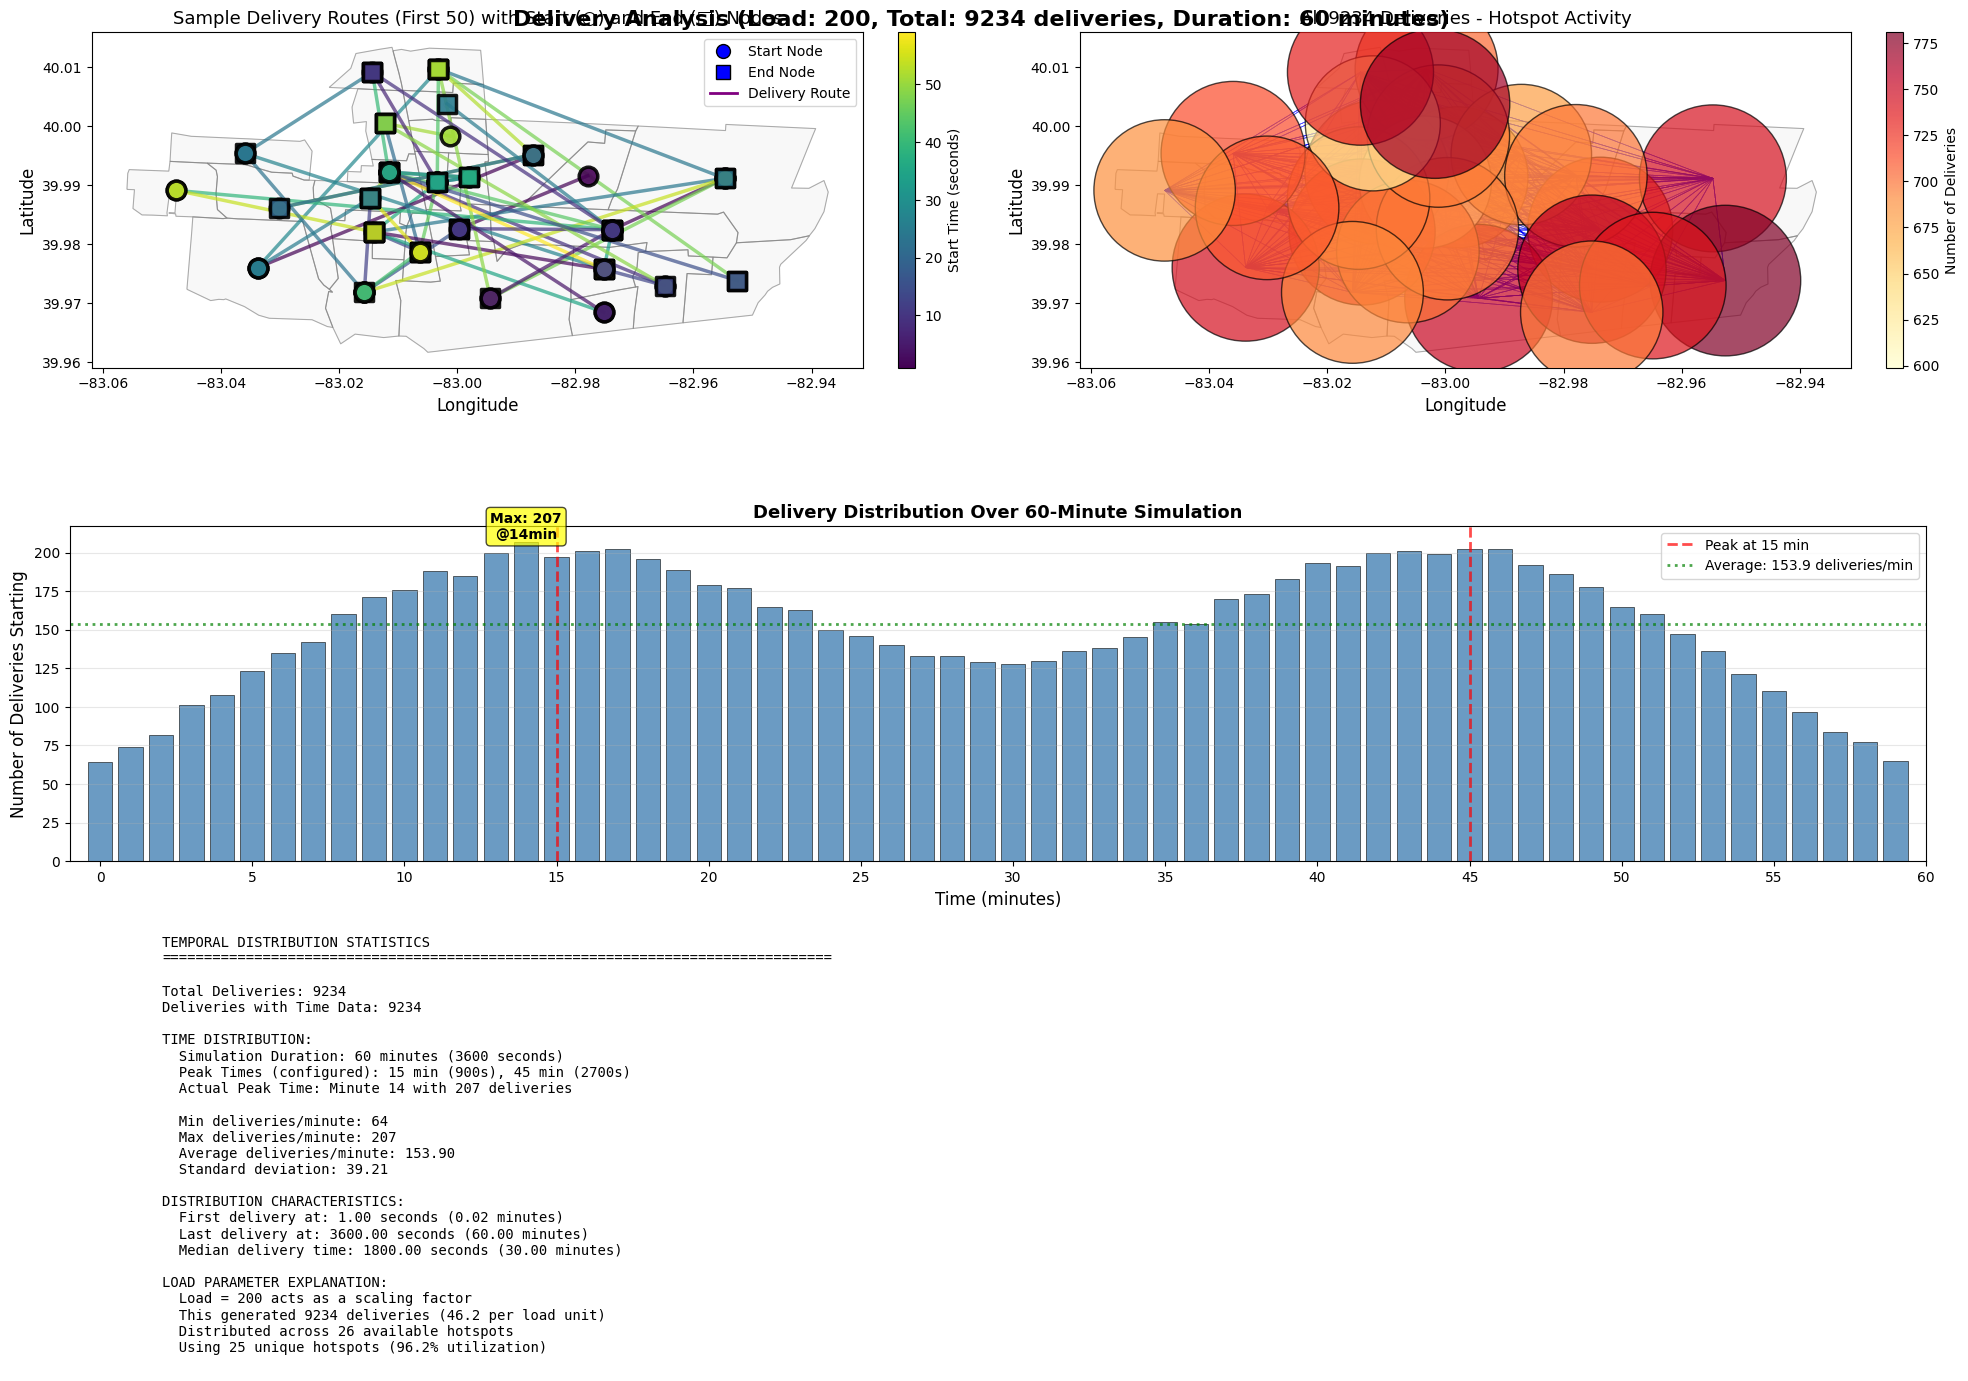


DELIVERIES PER MINUTE (First 20 minutes):
Minute     Time Range (s)       Count      Bar                           
------------------------------------------------------------
0          0-60                 64         ████████████████████████████████████████████████████████████████
1          60-120               74         ██████████████████████████████████████████████████████████████████████████
2          120-180              82         ██████████████████████████████████████████████████████████████████████████████████
3          180-240              101        █████████████████████████████████████████████████████████████████████████████████████████████████████
4          240-300              108        ████████████████████████████████████████████████████████████████████████████████████████████████████████████
5          300-360              123        ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
6     

In [962]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Extract delivery information
deliveries = deliverylist.deliveries

print(f"Total deliveries: {len(deliveries)}")
print(f"Number of hotspots (census tracts): {num_hotspots}")

# Create index mapping dictionaries
index_to_tract = {}
tract_to_index = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    index_to_tract[idx] = geoid
    tract_to_index[geoid] = idx

print(f"Created mapping for {len(index_to_tract)} census tracts")

# Extract delivery details
delivery_data = []
for i, delivery in enumerate(deliveries):
    data = {
        'delivery_id': i,
        'start_node': getattr(delivery, 'start_node', None),
        'end_node': getattr(delivery, 'end_node', None),
        'start_time': getattr(delivery, 'start_time', None),  # This is in seconds
        'num_shared': getattr(delivery, 'num_shared', 0) if hasattr(delivery, 'num_shared') else (len(delivery.shared) if hasattr(delivery, 'shared') and delivery.shared else 0)
    }
    delivery_data.append(data)

# Get hotspot locations using index mapping
index_to_location = {}
geoid_to_location = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    centroid = row.geometry.centroid
    location = (centroid.x, centroid.y)

    index_to_location[idx] = location
    geoid_to_location[geoid] = location

print(f"Location mappings created: {len(index_to_location)}")

# Determine which mapping to use
def get_location(node):
    """Get location for a node, handling both index and GEOID formats"""
    if node is None:
        return None

    # Try as string (GEOID)
    node_str = str(node)
    if node_str in geoid_to_location:
        return geoid_to_location[node_str]

    # Try as integer index
    try:
        node_int = int(float(node_str))
        if node_int in index_to_location:
            return index_to_location[node_int]
        # Try mapping index to GEOID first
        if node_int in index_to_tract:
            geoid = index_to_tract[node_int]
            if geoid in geoid_to_location:
                return geoid_to_location[geoid]
    except:
        pass

    return None

# Select sample deliveries to show
num_samples = min(50, len(delivery_data))
sample_deliveries = delivery_data[:num_samples]

# === PREPARE TIME-BASED DATA (IN SECONDS) ===
# Start times are already in seconds
start_times_seconds = [d['start_time'] for d in delivery_data if d['start_time'] is not None]
start_times_minutes = [t / 60.0 for t in start_times_seconds]  # Convert seconds to minutes for display

# Simulation duration
simulation_duration_seconds = deliverylist.hours * 3600  # hours to seconds
simulation_duration_minutes = deliverylist.hours * 60  # hours to minutes

# Create bins for each minute (0-60 minutes = 0-3600 seconds)
num_minutes = int(simulation_duration_minutes)
minute_bins_seconds = np.arange(0, simulation_duration_seconds + 60, 60)  # Bins in seconds (0, 60, 120, ..., 3600)
delivery_counts, bin_edges = np.histogram(start_times_seconds, bins=minute_bins_seconds)

print(f"\nTime Analysis:")
print(f"  Simulation duration: {deliverylist.hours} hour(s) = {simulation_duration_minutes} minutes = {simulation_duration_seconds} seconds")
print(f"  Deliveries with time data: {len(start_times_seconds)}")
if start_times_seconds:
    print(f"  Time range: {min(start_times_seconds):.2f} - {max(start_times_seconds):.2f} seconds")
    print(f"              ({min(start_times_seconds)/60:.2f} - {max(start_times_seconds)/60:.2f} minutes)")

# Create visualization with 3 plots
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1.5])

fig.suptitle(f'Delivery Analysis (Load: {deliverylist.load}, Total: {len(deliveries)} deliveries, Duration: {num_minutes} minutes)',
             fontsize=16, fontweight='bold')

# === PLOT 1: Deliveries with Start/End Nodes Highlighted ===
ax1 = fig.add_subplot(gs[0, 0])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax1, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax1, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Plot all hotspot centroids (faded)
for idx, loc in index_to_location.items():
    ax1.scatter(loc[0], loc[1], s=30, c='lightgray', marker='o',
               edgecolors='gray', linewidths=0.5, alpha=0.3, zorder=2)

# Get start times for coloring (in seconds)
start_times_sample = [d['start_time'] for d in sample_deliveries if d['start_time'] is not None]

if start_times_sample:
    norm = Normalize(vmin=min(start_times_sample), vmax=max(start_times_sample))
    cmap = viridis

    # Plot each delivery route with colored line
    routes_plotted = 0
    for data in sample_deliveries:
        if data['start_node'] is not None and data['end_node'] is not None and data['start_time'] is not None:
            start_loc = get_location(data['start_node'])
            end_loc = get_location(data['end_node'])

            if start_loc and end_loc:
                color = cmap(norm(data['start_time']))

                # Draw route line
                ax1.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                        color=color, alpha=0.7, linewidth=2.5, zorder=4)

                # Mark start node (circle)
                ax1.scatter(start_loc[0], start_loc[1], s=180, c=[color],
                           marker='o', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                # Mark end node (square)
                ax1.scatter(end_loc[0], end_loc[1], s=180, c=[color],
                           marker='s', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                routes_plotted += 1

    print(f"Routes plotted in sample: {routes_plotted}")

    # Add colorbar (show in minutes for readability)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1, label='Start Time (seconds)', fraction=0.046, pad=0.04)

# Add legend for markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Start Node'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='End Node'),
    Line2D([0], [0], color='purple', linewidth=2, label='Delivery Route')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title(f'Sample Delivery Routes (First {num_samples}) with Start (○) and End (□) Nodes', fontsize=13)
ax1.set_aspect('equal', adjustable='box')

# === PLOT 2: All Deliveries Overview with Density ===
ax2 = fig.add_subplot(gs[0, 1])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax2, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax2, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Count deliveries per hotspot for all deliveries
hotspot_activity = {}
for data in delivery_data:
    if data['start_node'] is not None:
        hotspot_activity[data['start_node']] = hotspot_activity.get(data['start_node'], 0) + 1
    if data['end_node'] is not None:
        hotspot_activity[data['end_node']] = hotspot_activity.get(data['end_node'], 0) + 1

# Plot hotspots sized and colored by activity
activities = []
locs_x = []
locs_y = []

for node, count in hotspot_activity.items():
    loc = get_location(node)
    if loc:
        activities.append(count)
        locs_x.append(loc[0])
        locs_y.append(loc[1])

if activities:
    # Plot with size proportional to activity
    sizes = [50 + a * 15 for a in activities]
    scatter = ax2.scatter(locs_x, locs_y, s=sizes, c=activities,
                         cmap='YlOrRd', edgecolors='black', linewidths=1,
                         alpha=0.7, zorder=5)

    # Add colorbar
    cbar2 = plt.colorbar(scatter, ax=ax2, label='Number of Deliveries',
                        fraction=0.046, pad=0.04)

# Plot all delivery routes (faded)
routes_total = 0
for data in delivery_data:
    if data['start_node'] is not None and data['end_node'] is not None:
        start_loc = get_location(data['start_node'])
        end_loc = get_location(data['end_node'])
        if start_loc and end_loc:
            ax2.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                    'b-', alpha=0.05, linewidth=0.5, zorder=2)
            routes_total += 1

print(f"Total routes plotted: {routes_total}")

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title(f'All {len(deliveries)} Deliveries - Hotspot Activity', fontsize=13)
ax2.set_aspect('equal', adjustable='box')

# === PLOT 3: Bar Chart - Deliveries per Minute ===
ax3 = fig.add_subplot(gs[1, :])

# Create bar chart (x-axis in minutes, but data binned from seconds)
minutes = np.arange(0, num_minutes)
bars = ax3.bar(minutes, delivery_counts, color='steelblue', edgecolor='black',
               linewidth=0.5, alpha=0.8)

# Highlight peak periods (peaks are in hours, convert to minutes)
# peaks=[0.25, 0.75] means 0.25*60=15 min and 0.75*60=45 min
peak_minutes = [p * 60 for p in deliverylist.peaks]
for peak_min in peak_minutes:
    if 0 <= peak_min < num_minutes:
        ax3.axvline(peak_min, color='red', linestyle='--', linewidth=2,
                   alpha=0.7, label=f'Peak at {peak_min:.0f} min' if peak_min == peak_minutes[0] else '')

# Add statistics
if len(delivery_counts) > 0:
    max_count = max(delivery_counts)
    max_minute = minutes[np.argmax(delivery_counts)]
    avg_count = np.mean(delivery_counts)

    ax3.axhline(avg_count, color='green', linestyle=':', linewidth=2,
               alpha=0.7, label=f'Average: {avg_count:.1f} deliveries/min')

    # Annotations
    ax3.text(max_minute, max_count, f'Max: {int(max_count)}\n@{int(max_minute)}min',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Time (minutes)', fontsize=12)
ax3.set_ylabel('Number of Deliveries Starting', fontsize=12)
ax3.set_title(f'Delivery Distribution Over {num_minutes}-Minute Simulation', fontsize=13, fontweight='bold')
ax3.set_xlim(-1, num_minutes)
ax3.set_xticks(np.arange(0, num_minutes + 1, 5))
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(loc='upper right', fontsize=10)

# === PLOT 4: Statistics Summary ===
ax4 = fig.add_subplot(gs[2, :])

# Calculate time-based statistics
if start_times_seconds and len(delivery_counts) > 0:
    time_stats = f"""
TEMPORAL DISTRIBUTION STATISTICS
{'='*80}

Total Deliveries: {len(deliveries)}
Deliveries with Time Data: {len(start_times_seconds)}

TIME DISTRIBUTION:
  Simulation Duration: {simulation_duration_minutes:.0f} minutes ({simulation_duration_seconds:.0f} seconds)
  Peak Times (configured): {', '.join([f'{p*60:.0f} min ({p*3600:.0f}s)' for p in deliverylist.peaks])}
  Actual Peak Time: Minute {int(max_minute)} with {int(max_count)} deliveries

  Min deliveries/minute: {int(min(delivery_counts))}
  Max deliveries/minute: {int(max_count)}
  Average deliveries/minute: {avg_count:.2f}
  Standard deviation: {np.std(delivery_counts):.2f}

DISTRIBUTION CHARACTERISTICS:
  First delivery at: {min(start_times_seconds):.2f} seconds ({min(start_times_seconds)/60:.2f} minutes)
  Last delivery at: {max(start_times_seconds):.2f} seconds ({max(start_times_seconds)/60:.2f} minutes)
  Median delivery time: {np.median(start_times_seconds):.2f} seconds ({np.median(start_times_seconds)/60:.2f} minutes)

LOAD PARAMETER EXPLANATION:
  Load = {deliverylist.load} acts as a scaling factor
  This generated {len(deliveries)} deliveries ({len(deliveries) / deliverylist.load:.1f} per load unit)
  Distributed across {num_hotspots} available hotspots
  Using {len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))} unique hotspots ({len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))/num_hotspots*100:.1f}% utilization)
"""
else:
    time_stats = "No time data available"

ax4.text(0.05, 0.5, time_stats, fontsize=10, family='monospace',
        verticalalignment='center', transform=ax4.transAxes)
ax4.axis('off')

plt.tight_layout()
plt.show()

# Print minute-by-minute breakdown for first 20 minutes
print("\n" + "="*60)
print("DELIVERIES PER MINUTE (First 20 minutes):")
print("="*60)
print(f"{'Minute':<10} {'Time Range (s)':<20} {'Count':<10} {'Bar':<30}")
print("-"*60)
for i in range(min(20, len(delivery_counts))):
    time_range = f"{i*60}-{(i+1)*60}"
    bar = '█' * int(delivery_counts[i])
    print(f"{i:<10} {time_range:<20} {int(delivery_counts[i]):<10} {bar}")

print(f"\n... Total across all {num_minutes} minutes: {int(sum(delivery_counts))} deliveries")

# Print sample deliveries with time in seconds
print("\n" + "="*100)
print(f"SAMPLE DELIVERIES (First 10):")
print("="*100)
print(f"{'ID':<5} {'Start Node':<12} {'End Node':<12} {'Start Time (s)':<15} {'Start Time (min)':<15} {'Shared':<8}")
print("-"*100)

for i, data in enumerate(delivery_data[:10]):
    start_node = str(data['start_node']) if data['start_node'] is not None else "N/A"
    end_node = str(data['end_node']) if data['end_node'] is not None else "N/A"
    start_time_s = f"{data['start_time']:.2f}" if data['start_time'] is not None else "N/A"
    start_time_m = f"{data['start_time']/60:.2f}" if data['start_time'] is not None else "N/A"

    print(f"{i+1:<5} {start_node:<12} {end_node:<12} {start_time_s:<15} {start_time_m:<15} {data['num_shared']:<8}")